# TVB-NetPyNE: Bridging multiscale activity by co-simulation

## Step-by-step learn how to perform a co-simulation embedding spiking neural networks into large-scale brain networks using TVB.

In [1]:
from IPython.display import Image, display

## Reduced Wong-Wang TVB mean field model

For every region node $n\prime$ modelled as a mean-field node in TVB:

(Post)Synaptic gating dynamics (i.e., proportion of synapse channels open at any given time):

$\dot{S_{n\prime}} = - \frac{1}{\tau}{S_{n\prime}}(t) + (1-{S_{n\prime}}(t))\gamma {R_{n\prime}}(t)$

and $ {R_{n\prime}}(t) $ is the postsynaptic firing rate given by:

$ {R_{n\prime}}(t) = H({I_{syn_{n\prime}}}(t), a, b, d) $

where

$ H({I_{syn_{n\prime}}}(t),  a, b, d) = \frac{aI_{syn_{n\prime}}(t)-b}{1-e^{-d(a{I_{syn_{n\prime}}}(t)-b)}}$ 

is a sigmoidal activation function of the input presynaptic current.

The total input presynaptic current to excitatory populations is given by: 

$ {I_{syn_{n\prime}}}(t) = I_o + w_+J_{N}{S_{n\prime}}(t) + GJ_{N}\sum_{{m\prime}\neq {n\prime}}C_{{m\prime}{n\prime}}S_{m\prime}(t-\tau_{{m\prime}{n\prime}})$

## Reduced Wong-Wang mean field model

### Parameters following Deco et al 2013:

- structural TVB connectivity weights $w_{{m\prime}{n\prime}}$ (${m\prime}->{n\prime}$)
- structural TVB connectivity delays $\tau_{{m\prime}{n\prime}}$  (${m\prime}->{n\prime}$)
- global structural brain connectivity coupling constant $G$
- overall effective external input current $I_o = 0.3nA$ 
- excitatory synaptic coupling $J_{N} = 0.2609nA$ 
- local excitatory recurrence $w_+ = 0.9$
- excitatory kinetic parameter $\gamma = 0.641 s$
- excitatory sigmoidal functions parameters $a = 2710nC^{-1}$, $b = 108Hz$, $d = 0.154s$

## Izhikevich Spiking network model in ANNarchy

For every neuron $i$ in region node $n$ modelled in ANNarchy as a spiking network:

Membrane potential:

$ \dot{V}_m = n_2V_m^2 + n_1V_m + n_0140 - U_m/C $

$\;\;\;\;\;\;\;- g_{AMPA}(V_m-E_{AMPA}) - g_{GABA}(V_m-E_{GABA}) - g_{BASE}V_m + I_e $

where the conductances follow the equations:

$ \dot{g}_{AMPA} = - g_{AMPA} / \tau_{AMPA} + \left[\sum_k \delta(t-t_k) \right]_{Exc}$

$ \dot{g}_{GABA} = - g_{GABA} / \tau_{GABA} + \left[\sum_k \delta(t-t_k) \right]_{Inh}$

$ \dot{g}_{BASE} = - g_{BASE} / \tau_{BASE} + \left[\sum_k \delta(t-t_k) \right]_{BASE}$

and recovery variable:

$ \dot{U}_m = a(bV_m - U_m)$


When $ V_m > V_{th} $ , $ V_m $ is set to $ c $, and $ U_m $ is incremented by $ d $.

# WORKFLOW:

In [2]:
import os
from collections import OrderedDict
import time
import numpy as np

from tvb.basic.profile import TvbProfile
TvbProfile.set_profile(TvbProfile.LIBRARY_PROFILE)

is_spiking_cortex = False # not yet fully functional if set to True

INTERFACE_COUPLING_MODE = "spikeNet" # "TVB"  or "spikeNet"
data_mode = "patient" # "control", or "patient"

simulation_mode = "rs"      # "stim" or "rs"
stim_target = "STN"         #     "STN"        "GPi"
stim_mode = "bi"            # "bi"  | "mono" | "simple"
                            # -------------------------
stim_freq = 130.0           # 130.0 |  120.0 |    0.0 
stim_ampl = 20.0            #  20.0 |  -35.0 |  -10.0 
stim_duration = 0.3         #   0.3 |    0.3 |    -

ctx_noise = 35.0 if is_spiking_cortex else 0.0

if simulation_mode == "stim":
    simulation_mode = simulation_mode + "_%s_%s" % (stim_target, stim_mode)
    if ctx_noise > 0.0:
        simulation_mode += "_n%g" % ctx_noise

from tvb_multiscale.tvb_netpyne.config import *

work_path = os.getcwd()
outputs_path = os.path.join(work_path, "outputs")
sim_mode_path = os.path.join(outputs_path, "TVBcortex_%s_coupl" % 
INTERFACE_COUPLING_MODE, 
                             data_mode, simulation_mode)
config = Config(output_base=sim_mode_path)
config.figures.SHOW_FLAG = True 
config.figures.SAVE_FLAG = True
config.figures.FIG_FORMAT = 'png'
config.figures.DEFAULT_SIZE= config.figures.NOTEBOOK_SIZE
FIGSIZE = config.figures.DEFAULT_SIZE

data_path = os.path.join(config.DATA_PATH, 'basal_ganglia')
fit_data_path = os.path.join(data_path, "ANNarchyFittedModels/dataFits_2020_02_05/databestfits", )

control_data = os.path.join(fit_data_path, "controlleft/OutputSim_Patient08.mat")
patient_data = os.path.join(fit_data_path, "patientleft/OutputSim_Patient09.mat")


if data_mode == "patient":
    subject_data = patient_data
    if INTERFACE_COUPLING_MODE == "TVB":
        STN_factor = 20.5 * 1e-2  # 0.205 
        dSN_factor = 22.2 * 1e-2  # 0.222 
        iSN_factor = 20.2 * 1e-2
    else:
        STN_factor = 55.0 * 1e-3  # 0.055 - 29.5
        dSN_factor = 35.5 * 1e-3  # 0.0355 - 19.7
        iSN_factor = 21.3 * 1e-3  # 0.0213 - 9.5
else:
    subject_data = control_data
    if INTERFACE_COUPLING_MODE == "TVB":
        STN_factor = 20.2 * 1e-2  # 0.202 
        dSN_factor = 23.4 * 1e-2  # 0.2340 
        iSN_factor = 21.1 * 1e-2  # 0.211 
    else:
        STN_factor = 45.6 * 1e-3  
        dSN_factor = 30.0 * 1e-3  
        iSN_factor = 19.5 * 1e-3

STN_correction = +0.01 + (20.0/21.0) * 1 / 0.174613435860374
dSN_correction = -0.01 + (20.0/21.0) * 1 / 0.19127125375089232
iSN_correction = -0.01 + (20.0/21.0) * 1 / 0.1001235833071405

STN_factor *= STN_correction
dSN_factor *= dSN_correction
iSN_factor *= iSN_correction
    
simulation_length = 1500.0
transient = 500.0
start_stimulus = 400.0
init_cond_jitter = 0.0

SPIKING_NODES_DELAYS = False


from tvb_multiscale.core.plot.plotter import Plotter
plotter = Plotter(config.figures)

# For interactive plotting:
# %matplotlib notebook  

# Otherwise:
%matplotlib inline 


2025-11-27 15:32:10,999 - WARNING - tvb.simulator.plot.tools - You need mpl_toolkits for some axe related features


/home/docker/venv/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Load structural data <br> (minimally a TVB connectivity)  <br> & prepare TVB simulator  <br> (region mean field model, integrator, monitors etc)

In [3]:
from tvb_multiscale.core.tvb.cosimulator.models.reduced_wong_wang_exc_io import ReducedWongWangExcIO

# ----------------------------------------------------------------------------------------------------------------
# ----Uncomment below to modify the simulator by changing the default options:--------------------------------------
# ----------------------------------------------------------------------------------------------------------------

from tvb.datatypes.connectivity import Connectivity
from tvb.simulator.integrators import HeunStochastic
from tvb.simulator.monitors import Raw  # , Bold, EEG

dt = 0.1
speed = np.array([4.0])

if is_spiking_cortex:
	conn_path = os.path.join(data_path, "conn_incl_cortex")

	w=np.zeros((11,11))
	c=np.loadtxt(os.path.join(conn_path, "aal_plus_BG_centers_incl_cortex.txt"), usecols=range(1,4))
	rl= np.loadtxt(os.path.join(conn_path, "aal_plus_BG_centers_incl_cortex.txt"), dtype="str", usecols=(0,))
	t= np.loadtxt(os.path.join(conn_path, "BGplusAAL_tract_lengths_incl_cortex.txt"))

	# Keep only the BG and a single Cortex node:
	c = c[:11]
	rl = rl[:11]
	rl[10] = "Cortex"
	w = w[:11][:, :11]
	t = t[:11][:, :11]

	# Keep only left hemisphere and the Cortex:
	inds = np.arange(0,10,2).astype("i").tolist() + [10]
	c = c[inds] 
	rl = rl[inds]
	print("Region labels:\n%s" % rl)
	# 0. GPe_Left, 1. GPi_Left, 2. STN_Left, 3. Striatum_Left, 4. Thal_Left, 5. Cortex
	w = w[inds][:, inds]
	t = t[inds][:, inds]
    

# 0. GPe_Left, 1. GPi_Left, 2. STN_Left, 3. Striatum_Left, 4. Thal_Left
BG_opt_matrix_weights = np.zeros((5, 5))
conn_mode = "subject" # subject" or "average"
if conn_mode == "average":
    weights_maith = np.array([1.93, 3.56, 1.46, 4.51, 3.52, 2.30, 2.34, 3.78, 1.98, 
                             1.30, 1.82, 3.56, 3.02, 1.78, 1.36, 2.27, 4.13, 2.74, 3.27])*1e-3  # controls
#     weights_maith = np.array([3.27, 3.80, 2.65, 3.66, 3.06, 3.06, 3.25, 4.02, 3.32, 
#                             2.98, 3.45, 3.64, 2.50, 2.12, 2.86, 2.79, 3.96, 3.69, 3.87])*1e-3   # patients
    # probs_maith = ????
else:
    import scipy.io as sio
    weights=sio.loadmat(subject_data)    # weights start from index 19
    weights_maith = weights["X"][0, 19:] # these are indices 19 till 37
    probs_maith = weights["X"][0, :19]   # these are indices 0 till 18

wdSNGPi = BG_opt_matrix_weights[3, 1] = weights_maith[0].item()
wiSNGPe = BG_opt_matrix_weights[3, 0] = weights_maith[1].item()
wGPeSTN = BG_opt_matrix_weights[0, 2] = weights_maith[2].item()
wSTNGPe = BG_opt_matrix_weights[2, 0] = weights_maith[3].item()
wSTNGPi = BG_opt_matrix_weights[2, 1] = weights_maith[4].item()
wGPeGPi = BG_opt_matrix_weights[0, 1] = weights_maith[5].item()  
wGPiTh = BG_opt_matrix_weights[1, 4] = weights_maith[8].item()
wThdSN = BG_opt_matrix_weights[4, 3] = weights_maith[10].item() # Th -> dSN
    
sliceBGnet = slice(0,5)
if is_spiking_cortex:
    w[sliceBGnet, sliceBGnet] = BG_opt_matrix_weights

wGPeGPe = weights_maith[6].item()   # "GPe" -> "GPe" 
wGPiGPi = weights_maith[7].item()   # "GPi" -> "GPi" 
wThiSN = weights_maith[9].item()    # "Eth" -> "IiSN" 

wdSNdSN = weights_maith[11].item()  # "IdSN" -> "IdSN" 
wiSNiSN = weights_maith[12].item()  # "IiSN" -> "IiSN" 
wCtxdSN = weights_maith[13].item()  # "CxE" -> "IdSN" 
wCtxiSN = weights_maith[14].item()  # "CxE" -> "IiSN" 
wCtxSTN = weights_maith[15].item()  # "CxE" -> "Estn"
wCtxEtoI = weights_maith[16].item() # "CxE" -> "CxI"
wCtxItoE = weights_maith[17].item() # "CxI" -> "CxE"
wCtxItoI = weights_maith[18].item() # "CxI" -> "CxI"

if is_spiking_cortex:
    w[5, 3] = wCtxdSN
    w[5, 2] = wCtxSTN

pdSNGPi = probs_maith[0].item()
piSNGPe = probs_maith[1].item()
pGPeSTN = probs_maith[2].item()
pSTNGPe = probs_maith[3].item()
pSTNGPi = probs_maith[4].item()
pGPeGPi = probs_maith[5].item()
pGPeGPe = probs_maith[6].item()     # "GPe" -> "GPe" 
pGPiGPi = probs_maith[7].item()     # "GPi" -> "GPi" 
pGPiTh = probs_maith[8].item()
pThiSN =  probs_maith[9].item()     # "Eth" -> "IiSN
pThdSN = probs_maith[10].item()     # Th --> dSN
pdSNdSN = probs_maith[11].item()    # "IdSN" -> "IdSN" 
piSNiSN = probs_maith[12].item()    # "IiSN" -> "IiSN" 
pCtxdSN = probs_maith[13].item()    # "CxE" -> "IdSN" 
pCtxiSN = probs_maith[14].item()    # "CxE" -> "IiSN" 
pCtxSTN = probs_maith[15].item()    # "CxE" -> "Estn"
pCtxEtoI = probs_maith[16].item()   # "CxE" -> "CxI"
pCtxItoE = probs_maith[17].item()   # "CxI" -> "CxE"
pCtxItoI = probs_maith[18].item()   # "CxI" -> "CxI"
pCtxCtx = probs_maith[16:19].mean() # "Ctx" -> "Ctx"

loadedParams ={'dSNGPi_probs': probs_maith[0],
    	'dSNGPi_weights'  : weights_maith[0],
    	'iSNGPe_probs'   : probs_maith[1],
    	'iSNGPe_weights'  : weights_maith[1],
    	'GPeSTN_probs'   : probs_maith[2],
    	'GPeSTN_weights'  : weights_maith[2],
    	'STNGPe_probs'   : probs_maith[3],
    	'STNGPe_weights'  : weights_maith[3],
    	'STNGPi_probs'   : probs_maith[4],
    	'STNGPi_weights' : weights_maith[4],
    	'GPeGPi_probs'   : probs_maith[5],
    	'GPeGPi_weights'  : weights_maith[5],
    	'GPeGPe_probs'   : probs_maith[6],
    	'GPeGPe_weights'  : weights_maith[6],
    	'GPiGPi_probs'   : probs_maith[7],
    	'GPiGPi_weights'  : weights_maith[7],
    	'GPiThal_probs'   : probs_maith[8],
    	'GPiThal_weights'  : weights_maith[8],
    	'ThaliSN_probs'   : probs_maith[9],
    	'ThaliSN_weights'  : weights_maith[9],
    	'ThaldSN_probs'   : probs_maith[10],
    	'ThaldSN_weights'  : weights_maith[10],
    	'dSNdSN_probs'   : probs_maith[11],
    	'dSNdSN_weights'  : weights_maith[11],
    	'iSNiSN_probs'   : probs_maith[12],
    	'iSNiSN_weights'  : weights_maith[12],
    	'CtxdSN_probs'   : probs_maith[13],
    	'CtxdSN_weights'  : weights_maith[13],
    	'CtxiSN_probs'   : probs_maith[14],
    	'CtxiSN_weights'  : weights_maith[14],
    	'CtxSTN_probs'   : probs_maith[15],
    	'CtxSTN_weights'  : weights_maith[15],
    	'CtxECtxI_probs'    : probs_maith[16],
    	'CtxECtxI_weights'  : weights_maith[16],
    	'CtxICtxE_probs'    : probs_maith[17],
    	'CtxICtxE_weights'  : weights_maith[17],
    	'CtxICtxI_probs'   : probs_maith[18],
    	'CtxICtxI_weights'  : weights_maith[18],}
if is_spiking_cortex:
    loadedParams.update({
        'CtxThal_weights': 0.0,
        'CtxThal_probs': 1.0})
print(loadedParams)

assert_loadedParams = dict(zip(loadedParams.values(), loadedParams.keys()))


{'dSNGPi_probs': 0.17859516634489409, 'dSNGPi_weights': 0.008694033162319101, 'iSNGPe_probs': 0.33518908071564507, 'iSNGPe_weights': 0.008090356577449711, 'GPeSTN_probs': 0.16505628454033283, 'GPeSTN_weights': 0.005997084264236037, 'STNGPe_probs': 0.3962228806747589, 'STNGPe_weights': 0.011259651579748606, 'STNGPi_probs': 0.24895916907698845, 'STNGPi_weights': 0.012728955057755228, 'GPeGPi_probs': 0.3252567500370787, 'GPeGPi_weights': 0.006170218545084936, 'GPeGPe_probs': 0.32325378120003734, 'GPeGPe_weights': 0.006765628813882359, 'GPiGPi_probs': 0.3371743973897537, 'GPiGPi_weights': 0.01216071144597663, 'GPiThal_probs': 0.24578932343574705, 'GPiThal_weights': 0.007014219544362278, 'ThaliSN_probs': 0.13343960522906853, 'ThaliSN_weights': 0.005992356203860255, 'ThaldSN_probs': 0.12055055752571203, 'ThaldSN_weights': 0.012069912539882353, 'dSNdSN_probs': 0.43455099617713133, 'dSNdSN_weights': 0.007630499957085704, 'iSNiSN_probs': 0.22354489027929958, 'iSNiSN_weights': 0.0141184567240998

In [4]:
# display(Image(filename='pics/Connectome.png',  width=1000, unconfined=False))

In [5]:
if not is_spiking_cortex:
      # Load full TVB connectome connectivity

      conn_path = os.path.join(data_path, "conn")

      #Load AAL atlas normative connectome including the Basal Ganglia regions from Petersen et al. atlas
      wTVB = np.loadtxt(os.path.join(conn_path, "conn_denis_weights.txt"))
      cTVB = np.loadtxt(os.path.join(conn_path, "aal_plus_BG_centers.txt"),usecols=range(1,4))
      rlTVB = np.loadtxt(os.path.join(conn_path, "aal_plus_BG_centers.txt"),dtype="str", usecols=(0,))
      tlTVB = np.loadtxt(os.path.join(conn_path, "BGplusAAL_tract_lengths.txt"))

      # Remove the second Thalamus, Pallidum (GPe/i), Putamen and Caudate (Striatum):
      inds_Th = (rlTVB.tolist().index("Thalamus_L"), rlTVB.tolist().index("Thalamus_R"))
      inds_Pall = (rlTVB.tolist().index("Pallidum_L"), rlTVB.tolist().index("Pallidum_R"))
      inds_Put = (rlTVB.tolist().index("Putamen_L"), rlTVB.tolist().index("Putamen_R"))
      inds_Caud = (rlTVB.tolist().index("Caudate_L"), rlTVB.tolist().index("Caudate_R"))
      inds_rm = inds_Th + inds_Pall + inds_Put + inds_Caud
      print("Connections of Thalami, Pallidum (GPe/i), Putamen and Caudate (Striatum) removed!:\n", 
            wTVB[inds_rm, :][:, inds_rm])
      wTVB = np.delete(wTVB, inds_rm, axis=0)
      wTVB = np.delete(wTVB, inds_rm, axis=1)
      tlTVB = np.delete(tlTVB, inds_rm, axis=0)
      tlTVB = np.delete(tlTVB, inds_rm, axis=1)
      rlTVB = np.delete(rlTVB, inds_rm, axis=0)
      cTVB = np.delete(cTVB, inds_rm, axis=0)

      number_of_regions = len(rlTVB)
      min_tt = speed.item() * 0.1
      sliceBG = [0, 1, 2, 3, 6, 7]
      sliceCortex = slice(10, number_of_regions)

      # Remove BG -> Cortex connections
      print("Removing BG -> Cortex connections with max:")
      print(wTVB[sliceCortex, :][:, sliceBG].max())
      wTVB[sliceCortex, sliceBG] = 0.0
      tlTVB[sliceCortex, sliceBG] = min_tt

      # Remove Cortex -> Thalamus connections
      sliceThal = [8, 9]
      print("Removing Cortex -> Thalamus connections with summed weight:")
      print(wTVB[sliceThal, sliceCortex].sum())
      wTVB[sliceThal, sliceCortex] = 0.0
      tlTVB[sliceThal, sliceCortex] = min_tt

      # Remove Cortex -> GPe/i connections
      sliceGP = [0, 1, 2, 3]
      print("Removing Cortex -> GPe/i connections with max:")
      print(wTVB[sliceGP, sliceCortex].max())
      wTVB[sliceGP,  sliceCortex] = 0.0
      tlTVB[sliceGP, sliceCortex] = min_tt

      # # Minimize all delays for the optimized network
      # tlTVB[:7][:, :7] = min_tt

      connTVB = Connectivity(region_labels=rlTVB, weights=wTVB, centres=cTVB, tract_lengths=tlTVB, speed=speed)

      # Normalize connectivity weights
      connTVB.weights = connTVB.scaled_weights(mode="region")
      connTVB.weights /= np.percentile(connTVB.weights, 99)

      # Keep only left hemisphere and remove Vermis:
      sliceLeft = slice(0, connTVB.number_of_regions -8, 2)

      connLeft = Connectivity(region_labels=connTVB.region_labels[sliceLeft], 
                              centres=connTVB.centres[sliceLeft],
                              weights=connTVB.weights[sliceLeft][:, sliceLeft],
                              tract_lengths=connTVB.tract_lengths[sliceLeft][:, sliceLeft], 
                              speed=connTVB.speed)
      connLeft.configure()

      print("\nLeft cortex connectome, after removing direct BG -> Cortex and intehemispheric BG <-> BG connections:")
      # plotter.plot_tvb_connectivity(connLeft);

Connections of Thalami, Pallidum (GPe/i), Putamen and Caudate (Striatum) removed!:
 [[   0.    0. 2642.    0.  781.    0.  200.    0.]
 [   0.    0.    0. 1034.    0.   45.    0. 1025.]
 [2642.    0.    0.    0. 6058.    0. 1337.    0.]
 [   0. 1034.    0.    0.    0.  162.    0.  381.]
 [ 781.    0. 6058.    0.    0.    0. 1026.    0.]
 [   0.   45.    0.  162.    0.    0.    0.  989.]
 [ 200.    0. 1337.    0. 1026.    0.    0.    0.]
 [   0. 1025.    0.  381.    0.  989.    0.    0.]]
Removing BG -> Cortex connections with max:
1931.34115274226
Removing Cortex -> Thalamus connections with summed weight:
4144.253554987011
Removing Cortex -> GPe/i connections with max:
1682.84151027352

Left cortex connectome, after removing direct BG -> Cortex and intehemispheric BG <-> BG connections:


In [6]:
if not is_spiking_cortex:
    sliceBGnet = slice(0,5)
    connTVBleftBG = Connectivity(region_labels=connLeft.region_labels[sliceBGnet], 
                                centres=connLeft.centres[sliceBGnet],
                                weights=connLeft.weights[sliceBGnet][:, sliceBGnet],
                                tract_lengths=connLeft.tract_lengths[sliceBGnet][:, sliceBGnet], 
                                speed=connLeft.speed)
    connTVBleftBG.configure()

    print("\nLeft BG TVB network:")
    # plotter.plot_tvb_connectivity(connTVBleftBG);



Left BG TVB network:


In [7]:
if not is_spiking_cortex:
    scaleBGoptTOtvb = np.percentile(BG_opt_matrix_weights, 95) /\
                    np.percentile(connTVBleftBG.weights, 95)
                    
    print("Scaling factor of TVB BG network connectome to optimal one = %g" % scaleBGoptTOtvb)
    # confitmed: 0.000771577


Scaling factor of TVB BG network connectome to optimal one = 0.000771577



Left BG optimized network:


<Figure size 640x480 with 0 Axes>

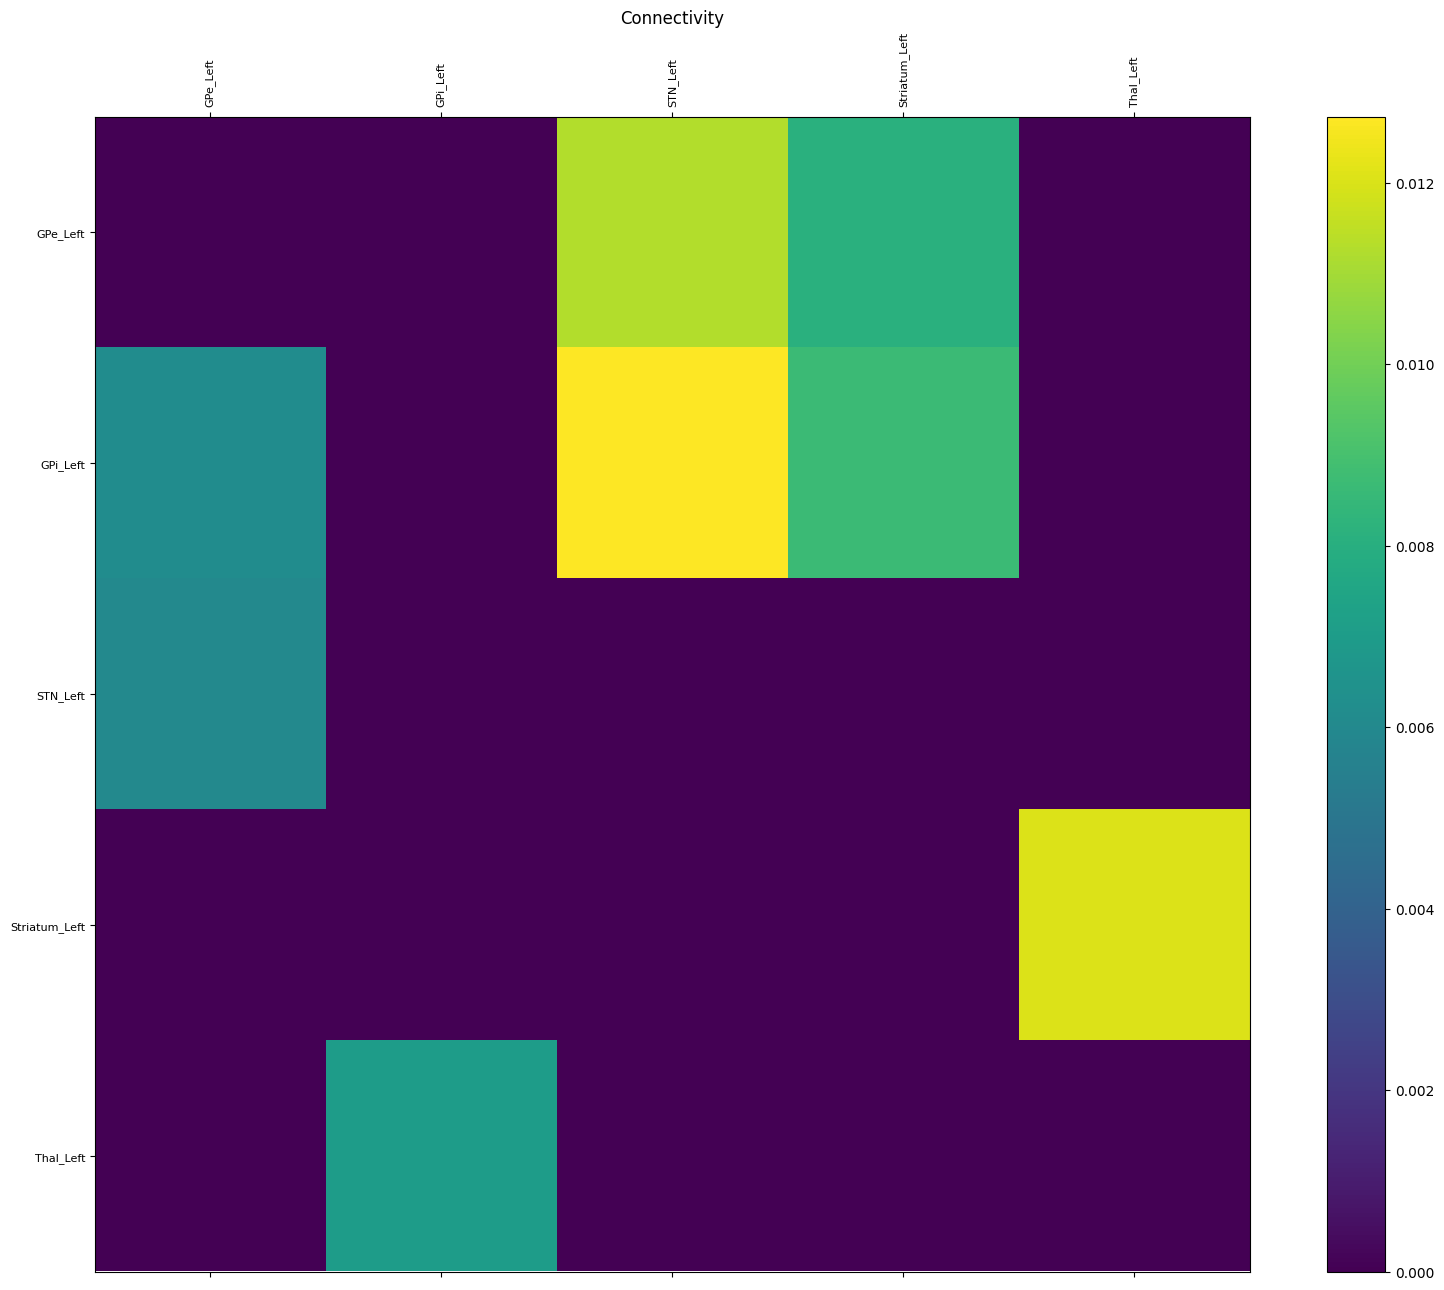

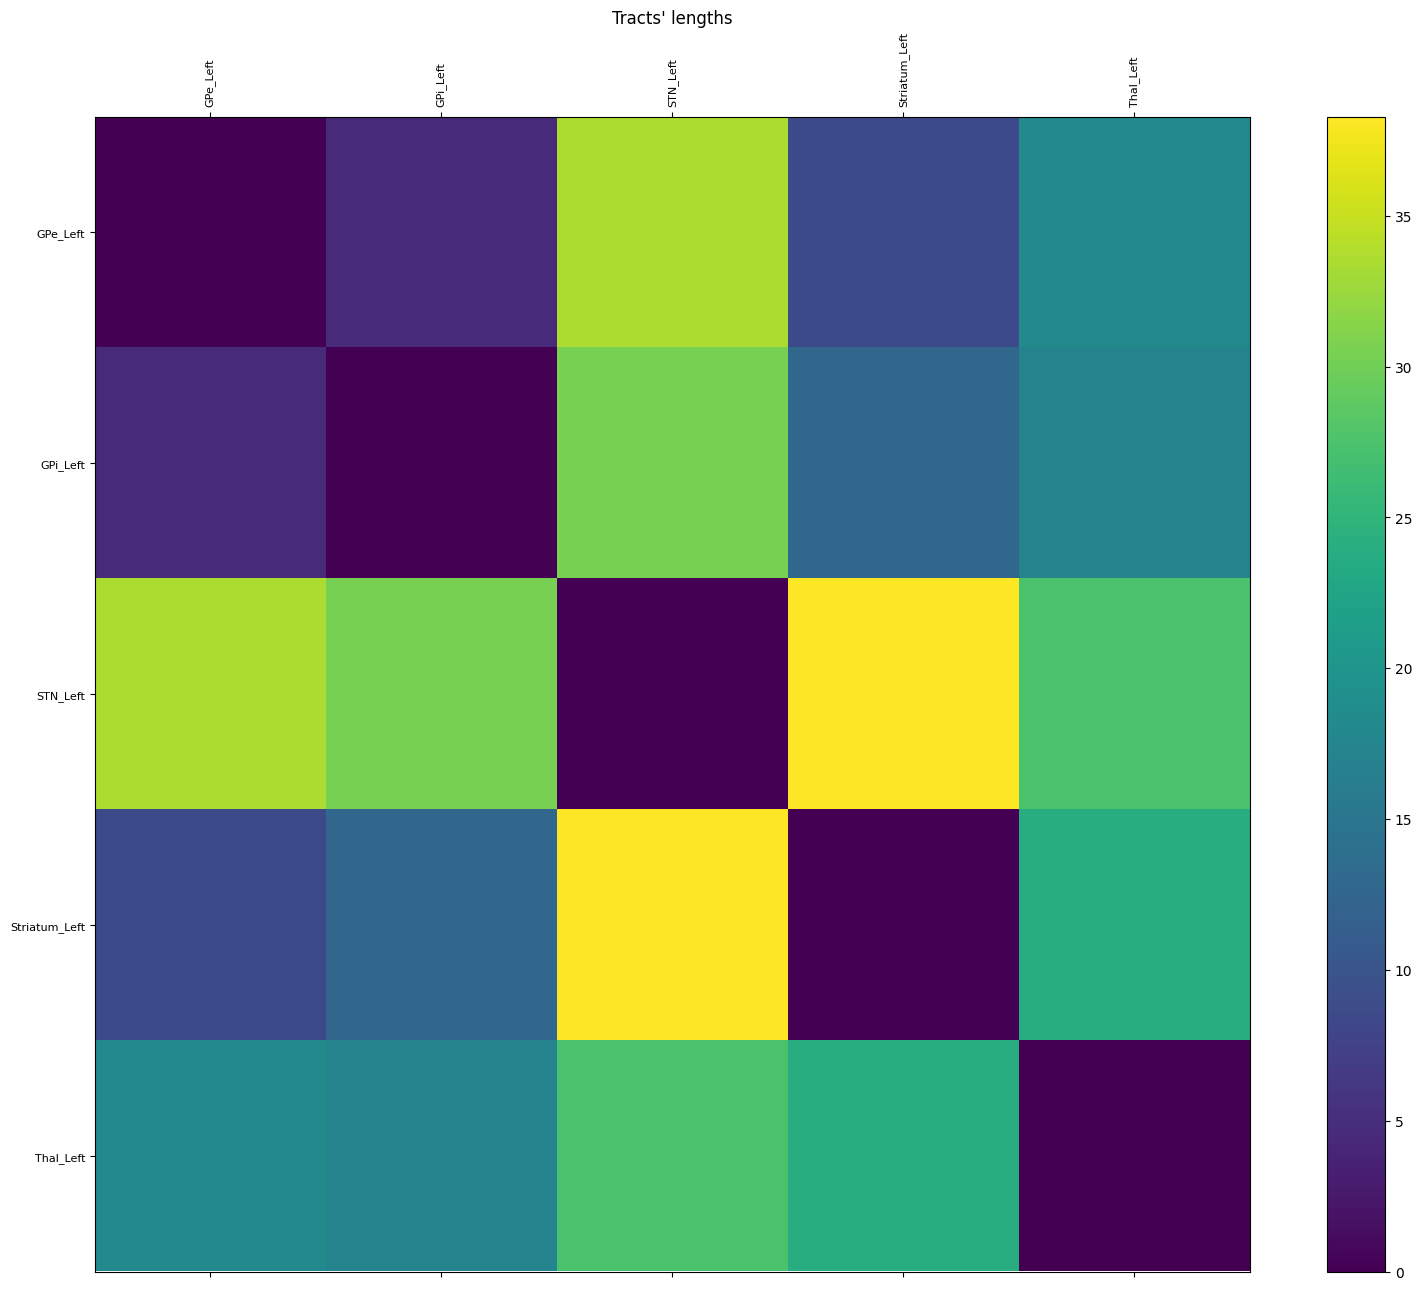

In [8]:
# Construct the final connectivity to use for simulation:
if is_spiking_cortex:
    if not SPIKING_NODES_DELAYS:
        t = dt * speed * np.ones(t.shape)
    connectivity=Connectivity(region_labels=rl,
                              weights=w.T, # !!!NOTE TVB indices convention!!!
                              centres=c,
                              tract_lengths=t,
                              speed=speed)

    connectivity.configure()
else:
    # Rescale the 
    ww = scaleBGoptTOtvb * np.array(connLeft.weights)
    ww[sliceBGnet, sliceBGnet] = BG_opt_matrix_weights.T  # !!!NOTE TVB indices convention Wi<-j!!!

    connectivity = Connectivity(region_labels=connLeft.region_labels, 
                                centres=connLeft.centres,
                                weights=ww, tract_lengths=connLeft.tract_lengths, 
                                speed=connLeft.speed)
    connectivity.configure()

    # Construct only the optimized BG connectivity only for plotting:
    connBGopt = Connectivity(region_labels=connectivity.region_labels[sliceBGnet], 
                            centres=connectivity.centres[sliceBGnet],
                            weights=connectivity.weights[sliceBGnet][:, sliceBGnet],
                            tract_lengths=connectivity.tract_lengths[sliceBGnet][:, sliceBGnet], 
                            speed=connectivity.speed)
    connBGopt.configure()

    print("\nLeft BG optimized network:")
    plotter.plot_tvb_connectivity(connBGopt);


In [9]:
from tvb_multiscale.core.tvb.cosimulator.cosimulator_serial import CoSimulatorSerial as CoSimulator

#white_matter_coupling = coupling.Linear(a=0.014)
# Create a TVB simulator and set all desired inputs
# (connectivity, model, surface, stimuli etc)
# We choose all defaults in this example
simulator = CoSimulator()
#simulator.use_numba = False
if is_spiking_cortex:
    model_params = {}
else:
    model_params = {"G": np.array([15.0/scaleBGoptTOtvb])}
simulator.model = ReducedWongWangExcIO(**model_params)

simulator.connectivity = connectivity

simulator.integrator = HeunStochastic()
simulator.integrator.dt = dt
simulator.integrator.noise.nsig = np.array([1e-4])  # 1e-5

mon_raw = Raw(period=1.0)  # ms
simulator.monitors = (mon_raw, )

if not is_spiking_cortex:
    init_cond_filepath = os.path.join(data_path, "tvb_init_cond_left.npy")
    init_cond = np.load(init_cond_filepath)   # 
    init_cond = np.abs(init_cond *(1 + init_cond_jitter * np.random.normal(size=init_cond.shape)))
    simulator.connectivity.set_idelays(simulator.integrator.dt)
    simulator.initial_conditions = init_cond * np.ones((simulator.connectivity.idelays.max(),
                                                        simulator.model.nvar,
                                                        simulator.connectivity.number_of_regions,
                                                        simulator.model.number_of_modes))
simulator.configure()

print("\nConnectome used for simulations:")
# plotter.plot_tvb_connectivity(simulator.connectivity);


# # Serializing TVB cosimulator is necessary for parallel cosimulation:
# from tvb_multiscale.core.utils.file_utils import dump_pickled_dict
# from tvb_multiscale.core.tvb.cosimulator.cosimulator_serialization import serialize_tvb_cosimulator
# sim_serial_filepath = os.path.join(config.out.FOLDER_RES, "tvb_serial_cosimulator.pkl")
# sim_serial = serialize_tvb_cosimulator(simulator)
# display(sim_serial)

# # Dumping the serialized TVB cosimulator to a file will be necessary for parallel cosimulation.
# dump_pickled_dict(sim_serial, sim_serial_filepath)

2025-11-27 15:32:12,455 - WARNING - tvb_multiscale.core.tvb.cosimulator.cosimulator_serial - There are no existing connections (i.e., with nonzero weights)!
Setting minimum delay to 1 integrator time step = 0.1!.
2025-11-27 15:32:12,455 - WARNING - tvb_multiscale.core.tvb.cosimulator.cosimulator_serial - Current step is not 0 upon configuration!
Setting it to 0. Initial condition might be affected!
Current step is not 0 upon configuration!
Setting it to 0. Initial condition might be affected!

Connectome used for simulations:


In [10]:
# display(Image(filename='pics/Network.png',  width=1000, unconfined=False))

## 2. Build and connect the NetPyNE network model <br> (networks of spiking neural populations for fine-scale <br>regions, stimulation devices, spike detectors etc)

In [11]:
from tvb_multiscale.tvb_netpyne.netpyne_models.models.basal_ganglia_izhikevich import BasalGangliaIzhikevichNetworkBuilder

# Select the regions for the fine scale modeling with ANNarchy spiking networks
spiking_nodes_ids = [0, 1, 2, 3, 4] # the indices of fine scale regions modeled with NetPyNE
if is_spiking_cortex:
    spiking_nodes_ids += [5]

# Build a NetPyNE network model with the corresponding builder
spiking_network_builder = BasalGangliaIzhikevichNetworkBuilder(simulator, spiking_nodes_ids, config=config)


# # ----------------------------------------------------------------------------------------------------------------
# # ----Uncomment below to modify the builder by changing the default options:--------------------------------------
# # ----------------------------------------------------------------------------------------------------------------
from copy import deepcopy

spiking_network_builder.population_order = 200 # reduce for speed

# When any of the properties model, params and scale below depends on regions,
# set a handle to a function with
# arguments (region_index=None) returning the corresponding property

from netpyne import specs
netParams = specs.NetParams()
netpyneCfg = specs.SimConfig()

netpyneCfg.recordStep = 1.0
netpyneCfg.allowSelfConns = True
# to change random seeds in NetPyNE
# netpyneCfg.seeds = {'conn': 4, 'stim': 4, 'loc': 4, 'cell': 4}
# to have more logs:
# netpyneCfg.verbose = True

def izhiCellParams(a, b, c, d, C, Ie, n0, n1, n2, uInit=-18.55, vInit=-70, vR=0, vThresh=30, noise=0):
    params = {
        'mod': 'Izhi2003c', # model name (corresponds to what described in .mod file)
        'vref': 'V', # custom variable for membrane potential in Izhi2003c
        'a': a, 'b': b, 'c': c, 'd': d,
        'C': C,
        'Ie': Ie,
        'n0': n0, 'n1': n1, 'n2': n2,
        'uInit': uInit, 'vInit': vInit,
        'Vr': vR,
        'thresh': vThresh,
        'noise': noise,
    }
    return {
        'secs': {
            'soma': {'pointps': {'izhi': params}}
        }
    }

#                                            a          b       c       d       C   Ie      n0          n1          n2
netParams.cellParams['Str'] = izhiCellParams(0.05,      -20,    -55,    377,   50,  0,      61.65119,   2.594639,   0.022799,   vR=-80,     vThresh=40)
netParams.cellParams['GPi'] = izhiCellParams(0.005,     0.585,  -65,    4,     1,   30,     140,        5,          0.04)
netParams.cellParams['GPe'] = izhiCellParams(0.005,     0.585,  -65,    4,     1,   12,     140,        5,          0.04)
netParams.cellParams['STN'] = izhiCellParams(0.005,     0.265,  -65,    2,     1,   3,      140,        5,          0.04)
netParams.cellParams['Thl'] = izhiCellParams(0.02,      0.25,   -65,    0.05,  1,   3.5,    140,        5,          0.04)

if is_spiking_cortex:
    netParams.cellParams['CxE'] = izhiCellParams(0.02,      0.2,    -72,    6,     1,   7,      140,        5,          0.04,       uInit=-14.0, vInit=-72, noise=ctx_noise) # I = 7 in resting, 50 when fitting
    netParams.cellParams['CxI'] = izhiCellParams(0.02,      0.2,    -72,    6,     1,   0,      140,        5,          0.04,       uInit=-14.0, vInit=-72)


Igpe_nodes_ids = [0]
Igpi_nodes_ids = [1]
Estn_nodes_ids = [2]
Eth_nodes_ids = [4]
Istr_nodes_ids = [3]

if is_spiking_cortex:
    Crtx_nodes_ids = [5]

I_nodes_ids = Igpe_nodes_ids + Igpi_nodes_ids
E_nodes_ids = Estn_nodes_ids + Eth_nodes_ids


# TODO: allow for having several nodes in single entry
spiking_network_builder.populations = [
    {"label": "E", "model": "STN",  
    #  "params":  paramsE_fun, 
     "nodes": Estn_nodes_ids, # E_nodes_ids,  # Estn in [2] # 
     "scale": 1.0},
    {"label": "E", "model": "Thl",  
    #  "params":  paramsE_fun, 
     "nodes": Eth_nodes_ids,  # Eth in [4]
     "scale": 1.0},
    {"label": "I", "model": "GPe",  
    #  "params": paramsI_fun, 
     "nodes": Igpe_nodes_ids,  # I_nodes_ids,  # Igpe in [0] # 
     "scale": 1.0},
    {"label": "I", "model": "GPi",  
    #  "params": paramsI_fun, 
     "nodes": Igpi_nodes_ids,  # Igpi in [1]
     "scale": 1.0},
    {"label": "IdSN", "model": "Str",   
    #  "params": paramsStr, 
     "nodes": Istr_nodes_ids,  # IdSN in [3]
     "scale": 1.0},
    {"label": "IiSN", "model": "Str",   # IiSN in [3]
    #  "params": paramsStr, 
     "nodes": Istr_nodes_ids,  # None means "all"
     "scale": 1.0}
]
if is_spiking_cortex:
    spiking_network_builder.populations += [
        {"label": "E", "model": "CxE",  
        #   "params":  paramsE_fun, 
          "nodes": Crtx_nodes_ids, # Cortex in [5]
          "scale": 3.0},
        {"label": "I", "model": "CxI",  
        #   "params": paramsI_fun, 
          "nodes": Crtx_nodes_ids,  # Cortex in [5]
          "scale": 0.75}
    ]


# Within region-node connections
# When any of the properties model, conn_spec, weight, delay, receptor_type below
# set a handle to a function with
# arguments (region_index=None) returning the corresponding property

synapse_model = None

def conn_spec_fixed_prob(prob=None):
    return {"rule": {"prob": prob}}

within_node_delay = 1.0

# for each connection, we have a different probability
spiking_network_builder.populations_connections = [
     #        source   ->   target
    {"source": "I", "target": "I",  # I -> I This is a self-connection for population "Igpe"
     "synapse_model": synapse_model, "conn_spec": conn_spec_fixed_prob(pGPeGPe),  # conn_spec
     "weight": np.abs(wGPeGPe).item(), "delay": within_node_delay,
     "receptor_type": "gaba", "nodes": Igpe_nodes_ids},  # None means apply to all
    {"source": "I", "target": "I",  # I -> I This is a self-connection for population "Igpi"
     "synapse_model": synapse_model, "conn_spec": conn_spec_fixed_prob(pGPiGPi),  # conn_spec
     "weight": np.abs(wGPiGPi).item(), "delay": within_node_delay,
     "receptor_type": "gaba", "nodes": Igpi_nodes_ids},  # None means apply to all
    {"source": "IdSN", "target": "IdSN",  # IdSN -> IdSN This is a self-connection for population "IdSN"
     "synapse_model": synapse_model, "conn_spec": conn_spec_fixed_prob(pdSNdSN),  # conn_spec
     "weight": np.abs(wdSNdSN).item(), "delay": within_node_delay,
     "receptor_type": "gaba", "nodes": Istr_nodes_ids},
    {"source": "IiSN", "target": "IiSN",  # IiSN -> IiSN This is a self-connection for population "IiSN"
     "synapse_model": synapse_model, "conn_spec": conn_spec_fixed_prob(piSNiSN),  # conn_spec
     "weight": np.abs(wiSNiSN).item(), "delay": within_node_delay,
     "receptor_type": "gaba", "nodes": Istr_nodes_ids},
    ]

if is_spiking_cortex:
    spiking_network_builder.populations_connections += [
        {"source": "I", "target": "I",  # I -> I This is a self-connection for population "CxI"
         "synapse_model": synapse_model, "conn_spec": conn_spec_fixed_prob(pCtxItoI),  # conn_spec
         "weight": np.abs(wCtxItoI), "delay": within_node_delay,
         "receptor_type": "gaba", "nodes": Crtx_nodes_ids},
        {"source": "E", "target": "I",          # "CxE" -> "CxI"
         "synapse_model": synapse_model, "conn_spec": conn_spec_fixed_prob(pCtxEtoI),  # conn_spec
         "weight": np.abs(wCtxEtoI), "delay": within_node_delay,  
         "receptor_type": "ampa", "nodes": Crtx_nodes_ids},
        {"source": "I", "target": "E",          # "CxI" -> "CxE"
         "synapse_model": synapse_model, "conn_spec": conn_spec_fixed_prob(pCtxItoE),  # conn_spec
         "weight": np.abs(wCtxItoE), "delay": within_node_delay,  
         "receptor_type": "gaba", "nodes": Crtx_nodes_ids}   
    ]


# Among/Between region-node connections
# Given that only the AMPA population of one region-node couples to
# all populations of another region-node,
# we need only one connection type
        
# When any of the properties model, conn_spec, weight, delay, receptor_type below
# depends on regions, set a handle to a function with
# arguments (source_region_index=None, target_region_index=None)

from tvb_multiscale.core.spiking_models.builders.templates import scale_tvb_weight, tvb_delay

# We set global coupling scaling to 1.0,
# because we need the Maith et al optimized weights without any scaling:
spiking_network_builder.global_coupling_scaling = 1.0 
        
# Function that will return the TVB weight with optional scaling:
class TVBWeightFun(object):
    
    def __init__(self, 
                 global_coupling_scaling=spiking_network_builder.global_coupling_scaling, 
                 tvb_weights = spiking_network_builder.tvb_weights):
        self.global_coupling_scaling = float(global_coupling_scaling)
        self.tvb_weights = tvb_weights.copy()
    
    def __call__(self, source_node, target_node):
        return scale_tvb_weight(source_node, target_node, self.tvb_weights,
                                scale=self.global_coupling_scaling)

# Function that will return the TVB delay unless SPIKING_NODES_DELAYS == False:
tvb_delay_fun = \
    lambda source_node, target_node: \
        np.maximum(spiking_network_builder.tvb_dt, 
                   tvb_delay(source_node, target_node, spiking_network_builder.tvb_delays)) \
            if SPIKING_NODES_DELAYS else within_node_delay
    
    
spiking_network_builder.nodes_connections = [
    #        source    ->     target
    {"source": "IdSN", "target": "I",             # "IdSN" -> "Igpi"
     "synapse_model": synapse_model, "conn_spec": conn_spec_fixed_prob(pdSNGPi),  # conn_spec
     "weight": TVBWeightFun(),
     "delay": lambda source_node, target_node: tvb_delay_fun(source_node, target_node),  
     "receptor_type": "gaba", 
     "source_nodes": Istr_nodes_ids, 
     "target_nodes": Igpi_nodes_ids},  # None means apply to all
    {"source": "IiSN", "target": "I",            # "IiSN" -> "Igpe"
     "synapse_model": synapse_model, "conn_spec": conn_spec_fixed_prob(piSNGPe),  # conn_spec
     "weight": TVBWeightFun(),
     "delay": lambda source_node, target_node: tvb_delay_fun(source_node, target_node),  
     "receptor_type": "gaba", 
     "source_nodes": Istr_nodes_ids, 
     "target_nodes": Igpe_nodes_ids},  # None means apply to all
    {"source": "I", "target": "I",             # "Igpe" -> "Igpi"
     "synapse_model": synapse_model, "conn_spec": conn_spec_fixed_prob(pGPeGPi),  # conn_spec
     "weight": TVBWeightFun(),
     "delay": lambda source_node, target_node: tvb_delay_fun(source_node, target_node),  
     "receptor_type": "gaba", 
     "source_nodes": Igpe_nodes_ids, 
     "target_nodes": Igpi_nodes_ids},  # None means apply to all
    {"source": "I", "target": "E",              # "Igpi" -> "Eth"
     "synapse_model": synapse_model, "conn_spec": conn_spec_fixed_prob(pGPiTh),  # conn_spec
     "weight": TVBWeightFun(),
     "delay": lambda source_node, target_node: tvb_delay_fun(source_node, target_node),  
     "receptor_type": "gaba", 
     "source_nodes": Igpi_nodes_ids, 
     "target_nodes": Eth_nodes_ids},  # None means apply to all
    {"source": "I", "target": "E",             # "Igpe" -> "Estn"
     "synapse_model": synapse_model, "conn_spec": conn_spec_fixed_prob(pGPeSTN),  # conn_spec
     "weight": TVBWeightFun(),
     "delay": lambda source_node, target_node: tvb_delay_fun(source_node, target_node),  
     "receptor_type": "gaba", 
     "source_nodes": Igpe_nodes_ids, 
     "target_nodes": Estn_nodes_ids},  # None means apply to all
    {"source": "E", "target": "IdSN",   # "Eth" -> ["IdSN"] 
     "synapse_model": synapse_model, "conn_spec": conn_spec_fixed_prob(pThdSN),  # conn_spec
     "weight": wThdSN, # TVBWeightFun(),
     "delay": lambda source_node, target_node: tvb_delay_fun(source_node, target_node),  
     "receptor_type": "ampa", 
     "source_nodes": Eth_nodes_ids, 
     "target_nodes": Istr_nodes_ids},  # None means apply to all
    {"source": "E", "target": "IiSN",   # "Eth" -> ["IiSN"] 
     "synapse_model": synapse_model, "conn_spec": conn_spec_fixed_prob(pThiSN),  # conn_spec
     "weight": wThiSN,
     "delay": lambda source_node, target_node: tvb_delay_fun(source_node, target_node),  
     "receptor_type": "ampa", 
     "source_nodes": Eth_nodes_ids, 
     "target_nodes": Istr_nodes_ids},  # No
     {"source": "E", "target": "I",          # "Estn" -> ["Igpe"]
     "synapse_model": synapse_model, "conn_spec": conn_spec_fixed_prob(pSTNGPe),  # conn_spec
     "weight": TVBWeightFun(),
     "delay": lambda source_node, target_node: tvb_delay_fun(source_node, target_node),  
     "receptor_type": "ampa", 
     "source_nodes": Estn_nodes_ids, 
     "target_nodes": Igpe_nodes_ids},
    {"source": "E", "target": "I",          # "Estn" -> ["Igpi"]
     "synapse_model": synapse_model, "conn_spec": conn_spec_fixed_prob(pSTNGPi),  # conn_spec
     "weight": TVBWeightFun(),
     "delay": lambda source_node, target_node: tvb_delay_fun(source_node, target_node),  
     "receptor_type": "ampa", 
     "source_nodes": Estn_nodes_ids, 
     "target_nodes": Igpi_nodes_ids},
     ]
if is_spiking_cortex:
    Ectx = "E"
    spiking_network_builder.nodes_connections += [
        {"source": Ectx, "target": "E",          # "Ectx" -> "Eth"
     "model": synapse_model, "conn_spec": conn_spec_fixed_prob(0), # No probability here?!
     "weight": TVBWeightFun(),
     "delay": lambda source_node, target_node: tvb_delay_fun(source_node, target_node),  
     "receptor_type": "ampa", 
     "source_nodes": Crtx_nodes_ids, 
     "target_nodes": Eth_nodes_ids},
    {"source": Ectx, "target": "E",          # "Ectx" -> "Estn"
     "synapse_model": synapse_model, "conn_spec": conn_spec_fixed_prob(pCtxSTN),  # conn_spec
     "weight": TVBWeightFun(),
     "delay": lambda source_node, target_node: tvb_delay_fun(source_node, target_node),  
     "receptor_type": "ampa", 
     "source_nodes": Crtx_nodes_ids, 
     "target_nodes": Estn_nodes_ids},
    {"source": Ectx, "target": "IdSN",          # "Ectx" -> "IdSN" 
     "synapse_model": synapse_model, "conn_spec": conn_spec_fixed_prob(pCtxdSN),  # conn_spec
     "weight": wCtxdSN, # TVBWeightFun(),
     "delay": lambda source_node, target_node: tvb_delay_fun(source_node, target_node),  
     "receptor_type": "ampa", 
     "source_nodes": Crtx_nodes_ids, 
     "target_nodes": Istr_nodes_ids},
    {"source": Ectx, "target": "IiSN",          # "Ectx" -> "IiSN" 
     "synapse_model": synapse_model, "conn_spec": conn_spec_fixed_prob(pCtxiSN),  # conn_spec
     "weight": wCtxiSN, # TVBWeightFun(ann_model_builder.tvb_weights, 
                            # wCrtxdSNtoCrtxiSN * ann_model_builder.global_coupling_scaling),
     "delay": lambda source_node, target_node: tvb_delay_fun(source_node, target_node),  
     "receptor_type": "ampa", 
     "source_nodes": Crtx_nodes_ids,
     "target_nodes": Istr_nodes_ids}
    ]

# Creating  devices to be able to observe NetPyNE activity:

spiking_network_builder.output_devices = []

period = netpyneCfg.recordStep

# Creating  devices to be able to observe NetPyNE activity:
spike_recorder_params = {}
for pop in spiking_network_builder.populations:
    connections = OrderedDict({})
    #                      label <- target population
    connections[pop["label"]] = pop["label"]
    spiking_network_builder.output_devices.append(
        {"model": "spike_recorder", "params": deepcopy(spike_recorder_params),
         "connections": connections, "nodes": pop["nodes"]})  # None means apply to "all"

# Labels have to be different for every connection to every distinct population
multimeter_params = {
    'variables': {
        'v': {'sec':'soma','pointp':'izhi','var':'V'},
        'u': {'sec':'soma','pointp':'izhi','var':'u'},
        'gampa': {'sec':'soma','pointp':'izhi','var':'gampa'},
        'ggaba': {'sec':'soma','pointp':'izhi','var':'ggaba'},
    }
}
for pop in spiking_network_builder.populations:
    connections = OrderedDict({})
    #               label    <- target population
    connections[pop["label"] + "_ts"] = pop["label"]

    params = deepcopy(multimeter_params)
    if pop['model'] in ["STN", "GPi"]:
        params['variables']['Iinj'] = {'sec':'soma','pointp':'izhi','var':'Iinj'}

    spiking_network_builder.output_devices.append(
            {"model": "multimeter", "params": params,
             "connections": connections, "nodes": pop["nodes"]})  # None means apply to all


# # Create a spike stimulus input device
spiking_network_builder.input_devices = []  #

# ----------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------

spiking_network_builder.configure(netParams=netParams, simConfig=netpyneCfg)

def synaptic_weight_scale_func(is_coupling_mode_tvb):
    # TODO: to be tuned or removed?
    if is_coupling_mode_tvb: # "TVB"
        return 1 # 1e-2
    else: # "spikeNet"
        return 1 # 5


# spiking_network_builder.global_coupling_scaling *= simulator.model.G
spiking_network_builder.netpyne_synaptic_weight_scale = synaptic_weight_scale_func(is_coupling_mode_tvb=INTERFACE_COUPLING_MODE=="TVB")


netpyne_network = spiking_network_builder.build() # set_defaults=False

%matplotlib inline

--No graphics will be displayed.


NetPyNE will load mod-files from /home/docker/packages/tvb-multiscale/examples/tvb_netpyne/notebooks/default_aarch64.
2025-11-27 15:32:12,851 - INFO - tvb-multiscale - Configuring spiking network builder...
2025-11-27 15:32:12,851 - INFO - tvb-multiscale - Configuring spiking network builder...
2025-11-27 15:32:12,851 - INFO - tvb-multiscale - Configuring spiking network builder...
2025-11-27 15:32:12,853 - INFO - tvb-multiscale - Configuring populations...
2025-11-27 15:32:12,853 - INFO - tvb-multiscale - Configuring populations...
2025-11-27 15:32:12,853 - INFO - tvb-multiscale - Configuring populations...
2025-11-27 15:32:12,855 - INFO - tvb-multiscale - Configuring populations' connections within spiking region nodes...
2025-11-27 15:32:12,855 - INFO - tvb-multiscale - Configuring populations' connections within spiking region nodes...
2025-11-27 15:32:12,855 - INFO - tvb-multiscale - Configuring populations' connections within spiking region nodes...
2025-11-27 15:32:12,856 - INFO

dlopen failed - 
default_aarch64/aarch64/libnrnmech.so: undefined symbol: loc_point_process


In [12]:
# TODO: 6 pops vs 4 in annarchy (but should be okay, because of different way of setting spiking_network_builder.populations)
populations_sizes = []
print("Population sizes: ")
for pop in spiking_network_builder.populations:
    populations_sizes.append(int(np.round(pop["scale"] * spiking_network_builder.population_order)))
    print("%s: %d" % (pop["label"], populations_sizes[-1]))
    

Population sizes: 
E: 200
E: 200
I: 200
I: 200
IdSN: 200
IiSN: 200


In [13]:

# The stimuli models:

if simulation_mode != "rs":

    # amplitude in mV or V? Was V in Michmizos paper, but had value 5.
    # frequency in Hz and later divided by 1000 because time scale is ms
    # duration in ms!
    #dt inside annarchy needs to be <=0.01 to realize a 60µs pulse width, but setting it to that leads to errors. 
    # realistic "duration" parameter for DBSInput would be 0.06

    def DBSInput(stim_mode, t, amplitude, frequency, duration):
        kappa = 8
        ampfactor = 10

        def sin(time): return np.sin(2 * np.pi * (frequency / 1000) * time)


        h1 = sin(t)
        h1[h1 > 0] = 1; h1[h1 < 0] = 0

        if stim_mode.find("mono") > -1:

            h2 = sin(t + duration)
            h2[h2 > 0] = 1; h2[h2 < 0] = 0

            r = amplitude * kappa * h1 * (1 - h2)
            
        elif stim_mode.find("bi") > -1:

            h2 = sin(t - duration)
            h2[h2 > 0] = 1; h2[h2 < 0] = 0

            h4 = sin(t - ((ampfactor + 1) * duration))
            h4[h2 > 0] = 1; h4[h4 < 0] = 0

            i1 = amplitude * (1 + 1/ampfactor) * kappa * h1 * (1-h2)
            i2 = (-amplitude/ampfactor) * kappa * h1 * (1-h4)
            r = i1 + i2
        return r

    if stim_target.find("STN") > -1:
        stim_target_pop = "STN_Left.E" 
    else:
        stim_target_pop = "GPi_Left.I" 

In [14]:
# display(Image(filename='pics/Stimuli.png',  width=1000, unconfined=False))

## 3. Build the TVB-NetPyNE interface

In [15]:
# display(Image(filename='pics/TVB-ANNarchy.png',  width=1000, unconfined=False))

In [16]:
# display(Image(filename='pics/ANNarchy-TVB.png',  width=1000, unconfined=False))

In [17]:
from tvb_multiscale.tvb_netpyne.interfaces.models.basal_ganglia_izhikevich import BasalGangliaIzhikevichTVBNetpyneInterfaceBuilder

    
# Build a TVB-ANNarchy interface with all the appropriate connections between the
# TVB and ANNarchy modelled regions
tvb_spikeNet_model_builder = BasalGangliaIzhikevichTVBNetpyneInterfaceBuilder()

tvb_spikeNet_model_builder.config = config
tvb_spikeNet_model_builder.tvb_cosimulator = simulator            
tvb_spikeNet_model_builder.spiking_network = netpyne_network
# This can be used to set default tranformer and proxy models:
tvb_spikeNet_model_builder.model = "RATE"          # "RATE" (or "SPIKES", "CURRENT") TVB->ANNarchy interface
tvb_spikeNet_model_builder.input_flag = True   # If True, ANNarchy->TVB update will be implemented
tvb_spikeNet_model_builder.output_flag = True  # If True, TVB->ANNarchy coupling will be implemented
# If default_coupling_mode = "TVB", large scale coupling towards spiking regions is computed in TVB
# and then applied with no time delay via a single "TVB proxy node" / ANNarchy device for each spiking region,
# "1-to-1" TVB->ANNarchy coupling.
# If any other value, we need 1 "TVB proxy node" / ANNarchy device for each TVB sender region node, and
# large-scale coupling for spiking regions is computed in ANNarchy, 
# taking into consideration the TVB connectome weights and delays, 
# in this "1-to-many" TVB->ANNarchy coupling.
tvb_spikeNet_model_builder.default_coupling_mode = INTERFACE_COUPLING_MODE # "spikeNet" # "TVB" 
# Number of neurons per population to be used to compute population mean instantaneous firing rates:
tvb_spikeNet_model_builder.proxy_inds = np.array(spiking_nodes_ids)
tvb_spikeNet_model_builder.N_E = spiking_network_builder.population_order
tvb_spikeNet_model_builder.GPe_proxy_inds = np.array(Igpe_nodes_ids)
tvb_spikeNet_model_builder.GPi_proxy_inds = np.array(Igpi_nodes_ids)
tvb_spikeNet_model_builder.STN_proxy_inds = np.array(Estn_nodes_ids)
tvb_spikeNet_model_builder.Striatum_proxy_inds = np.array(Istr_nodes_ids)
tvb_spikeNet_model_builder.Thal_proxy_inds = np.array(Eth_nodes_ids)

# Set exclusive_nodes = True (Default) if the spiking regions substitute for the TVB ones:
tvb_spikeNet_model_builder.exclusive_nodes = True  

tvb_spikeNet_model_builder.output_interfaces = []
tvb_spikeNet_model_builder.input_interfaces = []

from tvb_multiscale.tvb_netpyne.interfaces.builders import NetpyneInputProxyModels

In [18]:

# TVB applies a global coupling scaling of coupling.a * model.G
tvb_spikeNet_model_builder.global_coupling_scaling = \
    tvb_spikeNet_model_builder.tvb_cosimulator.coupling.a[0].item() * tvb_spikeNet_model_builder.G
print("global_coupling_scaling = %g" % tvb_spikeNet_model_builder.global_coupling_scaling)

# Total TVB indegree weight to STN:
wTVBSTNs = simulator.connectivity.weights[Estn_nodes_ids, 5:].squeeze()
wTVBSTN = wTVBSTNs.sum().item()
print("wTVBSTN = %g" % wTVBSTN)
CTXtoSTNinds = 5 + np.where(wTVBSTNs > 0.0)[0] # indices of TVB regions coupling to STN

# Total TVB indegree weight to Striatum:
wTVBSNs = simulator.connectivity.weights[Istr_nodes_ids, 5:].squeeze()
wTVBSN = wTVBSNs.sum().item()
print("wTVBSN = %g" % wTVBSN)
CTXtoSNinds = 5 + np.where(wTVBSNs > 0.0)[0]  # indices of TVB regions coupling to Striatum

# Approximate effective scaling of TVB coupling to STN
# after normalizing with STN indegree and 
# multiplying with the Maith et al. optimized CTX -> STN weight
iwCtxSTN = STN_factor*wCtxSTN / wTVBSTN
print("iwCtxSTN = %g" % iwCtxSTN)

# Approximate effective scaling of TVB coupling to dSN
# after normalizing with Striatum indegree and 
# multiplying with the Maith et al. optimized CTX -> dSN weight
iwCtxdSN = dSN_factor*wCtxdSN / wTVBSN  
print("iwCtxdSN = %g" % iwCtxdSN)

# Approximate effective scaling of TVB coupling to iSN
# after normalizing with Striatum indegree and 
# multiplying with the Maith et al. optimized CTX -> iSN weight
iwCtxiSN = iSN_factor*wCtxiSN / wTVBSN
print("iwCtxiSN = %g" % iwCtxiSN)

# confirmed:
# global_coupling_scaling = 75.9402
# wTVBSTN = 0.013739
# wTVBSN = 0.0503774
# iwCtxSTN = 0.0530743
# iwCtxdSN = 0.00666963
# iwCtxiSN = 0.0045056


global_coupling_scaling = 75.9402
wTVBSTN = 0.013739
wTVBSN = 0.0503774
iwCtxSTN = 0.29001
iwCtxdSN = 0.0331428
iwCtxiSN = 0.0428125


In [19]:
# ----------------------------------------------------------------------------------------------------------------
# ----Uncomment below to modify the builder by changing the default options:--------------------------------------
# ----------------------------------------------------------------------------------------------------------------



# --------For spike transmission from TVB to ANNarchy devices acting as TVB proxy nodes with TVB delays:--------


# TVB -> ANNarchy


if tvb_spikeNet_model_builder.default_coupling_mode == "spikeNet":
    
    # If coupling is computing in ANNarchy, we need as many TVB proxies 
    # as TVB regions coupling to STN and Striatum
    proxy_inds = np.unique(np.concatenate([CTXtoSTNinds, CTXtoSNinds]))
    
    # This is the TVB coupling weight function that will determine the connections' weights 
    # from TVB proxies to the target STN and dSN/iSN populations:
    class TVBWeightFunInterface(object):
    
        def __init__(self, scaling):
            self.scaling = float(scaling)

        def __call__(self, source_node, target_node, tvb_weights):
            return (scale_tvb_weight(source_node, target_node, tvb_weights, scale=self.scaling))

    # A similar function for TVB coupling delays is also applied in the background 
    # without need to be explicitly defined by the user
    
# Optionally adjust interface scale factors here 
# to have the same result counter act possible changes to G and coupling.a:
STN_factor /= tvb_spikeNet_model_builder.global_coupling_scaling
dSN_factor /= tvb_spikeNet_model_builder.global_coupling_scaling
iSN_factor /= tvb_spikeNet_model_builder.global_coupling_scaling

# 
tvb_spikeNet_model_builder.synaptic_weight_scale_func = synaptic_weight_scale_func
    
tvb_spikeNet_model_builder.output_interfaces = []

spikeGeneratorsPopOrder = tvb_spikeNet_model_builder.N_E

if not is_spiking_cortex:
    # Mean spike rates are applied in parallel to all target neurons
    for trg_pop, target_nodes, conn_scaling, this_conn_spec, scale_factor in \
                    zip(["E", "IdSN", "IiSN"], # ANNarchy target populations
                        # Target region indices in ANNarchy:  
                        [tvb_spikeNet_model_builder.STN_proxy_inds, 
                        tvb_spikeNet_model_builder.Striatum_proxy_inds, 
                        tvb_spikeNet_model_builder.Striatum_proxy_inds], 
                        # Maith et al optimized... 
                        [wCtxSTN, wCtxdSN, wCtxiSN], # ...weights 
                        # ...and probabilities for CTX -> STN/Striatum connections
                        [conn_spec_fixed_prob(prob=pCtxSTN),  # pCtxSTN  
                        conn_spec_fixed_prob(prob=pCtxdSN),  # pCtxdSN
                        conn_spec_fixed_prob(prob=pCtxiSN)], # pCtxiSN
                        # Interface scaling factors scaled by TVB weights' indegree to STN/Striatum:
                        [STN_factor/wTVBSTN, dSN_factor/wTVBSN, iSN_factor/wTVBSN]):          
            
            scale_factor /= spikeGeneratorsPopOrder

            tvb_spikeNet_model_builder.output_interfaces.append(
                {"voi": np.array(["R"]),             # Source TVB state variable
                "populations": np.array([trg_pop]), # ANNarchy target population
                "model": "RATE",
                "spiking_proxy_inds": target_nodes, # Target region indices in ANNarchy
                # This spike generator device generates spike trains 
                # with autocorrelation corr at a time scale tau
                "proxy_model": NetpyneInputProxyModels.RATE,  # ANNarchyInputProxyModels.RATE_TO_SPIKES, # 
                
                # TODO: above needed?
                #  'transformer_params': {'scale_factor': np.array([1.0])}, # due to the way Netpyne generates spikes, no scaling by population size is needed

                "proxy_params": {
                    "number_of_neurons": spikeGeneratorsPopOrder,
                    "record_generated_spikes": False, # True to record/plot in netpyne raster plot
                },
                'conn_spec': this_conn_spec,  # dictionary of connection properties
                'coupling_mode': tvb_spikeNet_model_builder.default_coupling_mode
            })  # None means all here
            
            # For both coupling modes, we scale the TVB rate already at the TVB -> ANNarchy transformer
            # with the interface scale factor (normalized by TVB indegree to STN/Striatum)
            # and the global coupling scaling.
            if tvb_spikeNet_model_builder.output_interfaces[-1]["coupling_mode"] == "spikeNet":
    #             if trg_pop == "E":
    #                 tvb_spikeNet_model_builder.output_interfaces[-1]["proxy_inds"] = CTXtoSTNinds
    #             else:
    #                 tvb_spikeNet_model_builder.output_interfaces[-1]["proxy_inds"] = CTXtoSNinds
                tvb_spikeNet_model_builder.output_interfaces[-1]["proxy_inds"] = proxy_inds
                # In this case connections from each TVB proxy to STN/Striatum 
                # are scaled additionally with the Maith et al. optimized weights
                tvb_spikeNet_model_builder.output_interfaces[-1]["weights"] = TVBWeightFunInterface(conn_scaling)
                tvb_spikeNet_model_builder.output_interfaces[-1]["transformer_params"] = \
                    {"scale_factor": scale_factor * tvb_spikeNet_model_builder.global_coupling_scaling}
                # In total:
                # From each TVB proxy node we get a rate scaled as (
                # (coupling.a * G * STN_factor/wTVBSTN) * R_i, (i for all TVB regions)
                # Then, spikes generated from each TVB proxy are transferred via connections 
                # with weights TVB_w_ji * wCtxSTN or wCtxiSN or wCtxdSN (j for STN or Striatum) 
                # and probabilities pCtxSTN or pCtxiSN or pCtxdSN, respectively
            else:
                # In this case connections from each TVB proxy to STN/Striatum 
                # are equal to the Maith et al. optimized weights
                tvb_spikeNet_model_builder.output_interfaces[-1]["weights"] = conn_scaling
                # In this case coupling.a is already applied during computing TVB coupling.
                # Therefore we scale only with model.G
                tvb_spikeNet_model_builder.output_interfaces[-1]["transformer_params"] = \
                    {"scale_factor": scale_factor * tvb_spikeNet_model_builder.G}
                # In total:
                # From each TVB proxy node we get a total coupling rate scaled 
                # as (coupling.a * G STN_factor/wTVBSTN) * R_j, (j for STN or Striatum)
                # Then, spikes generated from each TVB proxy are transferred via connections 
                # with weights wCtxSTN or wCtxiSN or wCtxdSN and 
                # probabilities pCtxSTN or pCtxiSN or pCtxdSN, respectively

from tvb_multiscale.core.interfaces.transformers.models.red_wong_wang import ElephantSpikesRateRedWongWangExc

tvb_spikeNet_model_builder.input_interfaces = []
# TVB <-- ANNarchy:
for src_pop, nodes, in zip(
                # Source populations in ANNarchy:
                [np.array(["I"]),  np.array(["E"]), np.array(["IdSN", "IiSN"])],
                # Source regions indices in ANNarchy:
                [tvb_spikeNet_model_builder.I_proxy_inds,          # GPe and GPi
                 tvb_spikeNet_model_builder.E_proxy_inds,          # STN and Thalamus
                 tvb_spikeNet_model_builder.Striatum_proxy_inds]): # Striatum
        #            TVB <- ANNarchy
        tvb_spikeNet_model_builder.input_interfaces.append(
            {"voi": np.array(["S", "R"]),  # Target state variables in TVB
             "populations": src_pop,  # Source populations in ANNarchy
             # This transformer not only converts spike counts to rates for state variable R,
             # but also integrates the dS/dt to compute the respective S!:
             "transformer": ElephantSpikesRateRedWongWangExc,
             "transformer_params": 
                 # Spike counts are converted to rates via:
                 # number_of_spikes / number_of_neurons_per_population / number_of_populations
                 # (mind that there are 2 populations in Striatum)
                 {"scale_factor": np.array([1.0]) / tvb_spikeNet_model_builder.N_E / len(src_pop),
                  # The integrator used to integrate dS/dt
                   "integrator":CONFIGURED.DEFAULT_TRANSFORMER_INTEGRATOR_MODEL(
                                       dt=simulator.integrator.dt),
                    "state": np.zeros((2, len(nodes))), # initial condition
                    # Parameters of the dS/dt differential equation:
                    "tau_s": simulator.model.tau_s, # time constant of integrating S
                    "tau_r": np.array([10.0]),      # time constant of integrating R to low pass filter it
                    "gamma": simulator.model.gamma}, 
             "proxy_inds": np.array(nodes)})  # None means all here
    

# ----------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------

# Configure and build:
tvb_spikeNet_model_builder.configure()
# tvb_spikeNet_model_builder.print_summary_info_details(recursive=1)
    
print("\noutput (TVB->NetPyNE coupling) interfaces' configurations:\n")
display(tvb_spikeNet_model_builder.output_interfaces)
    
print("\ninput (NetPyNE->TVB update) interfaces' configurations:\n")
display(tvb_spikeNet_model_builder.input_interfaces)
    
    


output (TVB->NetPyNE coupling) interfaces' configurations:



[{'voi': array([1]),
  'populations': array(['E'], dtype='<U1'),
  'model': 'RATE',
  'spiking_proxy_inds': array([2]),
  'proxy_params': {'number_of_neurons': 200, 'record_generated_spikes': False},
  'conn_spec': {'rule': {'prob': 0.174613435860374}},
  'coupling_mode': 'spikeNet',
  'proxy_inds': array([ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21,
         22, 23, 35, 41]),
  'weights': <__main__.TVBWeightFunInterface at 0xffff09f51b80>,
  'voi_labels': array(['R'], dtype='<U1'),
  'monitor_ind': 0,
  'proxy': tvb_multiscale.tvb_netpyne.interfaces.io.NetpynePoissonGeneratorSet,
  'transformer': <tvb_multiscale.core.interfaces.transformers.models.base.LinearRate at 0xffff09fb3350>},
 {'voi': array([1]),
  'populations': array(['IdSN'], dtype='<U4'),
  'model': 'RATE',
  'spiking_proxy_inds': array([3]),
  'proxy_params': {'number_of_neurons': 200, 'record_generated_spikes': False},
  'conn_spec': {'rule': {'prob': 0.19127125375089232}},
  'coupling_mode': 'spik


input (NetPyNE->TVB update) interfaces' configurations:



[{'voi': array([0, 1]),
  'populations': array(['I'], dtype='<U1'),
  'transformer': <tvb_multiscale.core.interfaces.transformers.models.red_wong_wang.ElephantSpikesRateRedWongWangExc at 0xffff09fb0e60>,
  'proxy_inds': array([0, 1]),
  'voi_labels': array(['S', 'R'], dtype='<U1'),
  'proxy': tvb_multiscale.tvb_netpyne.interfaces.io.NetpyneSpikeRecorderSet},
 {'voi': array([0, 1]),
  'populations': array(['E'], dtype='<U1'),
  'transformer': <tvb_multiscale.core.interfaces.transformers.models.red_wong_wang.ElephantSpikesRateRedWongWangExc at 0xffff09fb0ef0>,
  'proxy_inds': array([2, 4]),
  'voi_labels': array(['S', 'R'], dtype='<U1'),
  'proxy': tvb_multiscale.tvb_netpyne.interfaces.io.NetpyneSpikeRecorderSet},
 {'voi': array([0, 1]),
  'populations': array(['IdSN', 'IiSN'], dtype='<U4'),
  'transformer': <tvb_multiscale.core.interfaces.transformers.models.red_wong_wang.ElephantSpikesRateRedWongWangExc at 0xffff09fb1100>,
  'proxy_inds': array([3]),
  'voi_labels': array(['S', 'R'], d

In [20]:

simulator = tvb_spikeNet_model_builder.build()

from neuron import h
from netpyne import sim

if simulation_mode != "rs":
    start_stim = np.ceil(start_stimulus / simulator.synchronization_time) * simulator.synchronization_time
    
    if simulation_mode.find("simpl") > -1:
        # for stimulus application:
        pass
    else:
        # for stimulus application:
        t = np.arange(0, simulation_length, spiking_network_builder.spiking_dt)
        stimVector = DBSInput(simulation_mode, t, stim_ampl, stim_freq, stim_duration)

        # switch the stimulation off for the first time segment
        stimVector[:int(start_stim / spiking_network_builder.spiking_dt)] = 0
        stimVector = h.Vector(stimVector)
        for cellGid in sim.net.pops[stim_target_pop].cellGids:
            cell = sim.net.cells[cellGid]
            stimVector.play(cell.secs.soma.pointps.izhi.hObj._ref_Iinj, spiking_network_builder.spiking_dt)

if is_spiking_cortex and (ctx_noise > 0):
    rand = h.Random()
    from netpyne import sim
    for ctxCellGid in sim.net.pops['Cortex.E'].cellGids:
        ctxCell = sim.net.cells[ctxCellGid]
        rand.Random123(sim.hashStr('ctxnoiserand'), ctxCellGid) # use cell gid as seed
        rand.normal(0, 1)
        rand.play(ctxCell.secs.soma.pointps.izhi.hObj._ref_mu)

simulator.simulate_spiking_simulator = netpyne_network.netpyne_instance.run  # set the method to run NetPyNE
    
# simulator.print_summary_info(recursive=3)
# simulator.print_summary_info_details(recursive=3)
    
print("\n\noutput (TVB->NetPyNE coupling) interfaces:\n")
simulator.output_interfaces.print_summary_info_details(recursive=2)
    
print("\n\ninput (NetPyNE->TVB update) interfaces:\n")
simulator.input_interfaces.print_summary_info_details(recursive=2)


2025-11-27 15:32:14,231 - INFO - tvb_multiscale.core.spiking_models.devices - <class 'tvb_multiscale.core.spiking_models.devices.DeviceSet'> of model poisson_generator for ['R']->['E'] created!
2025-11-27 15:32:14,231 - INFO - tvb_multiscale.core.spiking_models.devices - <class 'tvb_multiscale.core.spiking_models.devices.DeviceSet'> of model poisson_generator for ['R']->['E'] created!
Netpyne:: will create internal device ['R']->['E'] - Precentral_L. Model: poisson_generator, params: {'number_of_neurons': 200, 'record_generated_spikes': False}
Netpyne:: Creating artif cells for node '['R']->['E'] - Precentral_L' of 200 neurons
Netpyne:: will connect input device poisson_generator. ['R']->['E'] - Precentral_L -> STN_Left.E (weight: 2.4410120537741323e-05, delay: 17.950000762939453)
Netpyne:: will create internal device ['R']->['E'] - Frontal_Sup_2_L. Model: poisson_generator, params: {'number_of_neurons': 200, 'record_generated_spikes': False}
Netpyne:: Creating artif cells for node '['



Creating network of 69 cell populations on 1 hosts...:   0% 0/69 [00:00<?, ?it/s]

AssertionError: Cell rule labeled 'art_NetStim' is a compartment cell, but it doesn't have required entry 'secs'.
If this cell is expected to be a point cell instead, make sure the correspondent mechanism is included and compiled.

## 3. Configure simulator, simulate, gather results

In [ ]:
simulation_length = \
            np.ceil(simulation_length / simulator.synchronization_time) * simulator.synchronization_time
simulator.simulation_length = simulation_length

# The netpyne_network.configure() should be called after simulation_length is properly configured in simulator
netpyne_network.configure()
netpyne_network.print_summary_info_details(recursive=2, connectivity=False)


In [ ]:
 # -----------------------------------5. Simulate and gather results-------------------------------------------------
# ...and simulate!

t_start = time.time()

if is_spiking_cortex:
    netpyne_network.netpyne_instance.run(simulation_length)
    results = None
else:
    results = simulator.run(simulation_length=simulation_length, 
                        advance_simulation_for_delayed_monitors_output=True
                        ) # 35.0 with stimulus application
    
print("\nSimulated in %f secs!" % (time.time() - t_start))

netpyne_network.netpyne_instance.finalize()


In [ ]:
from netpyne import sim
# # to exclude proxy devises pops:
# popIds = [id for id in sim.net.pops.keys()][:6]
sa = sim.analysis
sa.popAvgRates(tranges=[transient, simulation_length])
# %matplotlib inline
# sim.analysis.plotConn(showFig=True, includePre=popIds, includePost=popIds, feature='weight');
# sim.analysis.plotConn(showFig=True, includePre=popIds, includePost=popIds, feature='prob');

## 4. Plot results and write them to HDF5 files

In [ ]:
# set to False for faster plotting of only mean field variables and dates, apart from spikes" rasters:
from scipy.io import savemat
plot_per_neuron = False  
MAX_VARS_IN_COLS = 3
MAX_REGIONS_IN_ROWS = 10
MIN_REGIONS_FOR_RASTER_PLOT = 9


### TVB plots

In [ ]:
# If you want to see what the function above does, take the steps, one by one
try:
    # We need framework_tvb for writing and reading from HDF5 files
    from tvb_multiscale.core.tvb.io.h5_writer import H5Writer
    from examples.plot_write_results import write_RegionTimeSeriesXarray_to_h5
    writer = H5Writer()
except:
    writer = False
    
# Put the results in a Timeseries instance
from tvb.contrib.scripts.datatypes.time_series_xarray import TimeSeriesRegion as TimeSeriesXarray

source_ts = TimeSeriesXarray(  # substitute with TimeSeriesRegion fot TVB like functionality
        data=results[0][1], time=results[0][0] - results[0][0][0],
        connectivity=simulator.connectivity,
        labels_ordering=["Time", "State Variable", "Region", "Neurons"],
        labels_dimensions={"State Variable": list(simulator.model.variables_of_interest),
                           "Region": simulator.connectivity.region_labels.tolist()},
        sample_period=simulator.integrator.dt)
source_ts.configure()

t = source_ts.time

datadict = source_ts._data.to_dict()
datadict["transient"] = transient
savemat(os.path.join(config.out.FOLDER_RES, "tvb_timeseries.mat"), datadict)
del datadict

# Write to file
if writer:
    write_RegionTimeSeriesXarray_to_h5(source_ts, writer,
                                       os.path.join(config.out.FOLDER_RES, source_ts.title)+".h5")
    
source_ts


# init_cond = source_ts[-100:]._data.values.mean(axis=0)
# init_cond[2:] = 0.0
# init_cond[1:, 5:] = 0.0
# np.save(init_cond_filepath, init_cond)


In [ ]:
TVBrate = source_ts[transient:][:, "R", 5:]._data.values.mean(axis=0).squeeze()
TVBrateSTNeff = TVBrate[wTVBSTNs > 0.0].mean()
TVBrateSNeff = TVBrate[wTVBSNs > 0.0].mean()
TVBrateSTN = (TVBrate * wTVBSTNs * STN_factor).sum()
TVBratedSN = (TVBrate * wTVBSNs  * dSN_factor).sum()
TVBrateiSN = (TVBrate * wTVBSNs  * iSN_factor).sum() 
mean_tvb_rate = TVBrate.mean()
total_tvb_rate = TVBrate.sum()
print("Mean TVB rate = %g" % mean_tvb_rate)
print("Total TVB rate = %g" % total_tvb_rate)
print("Total weighted TVB rate to STN = %g ~= %g (expected) ~= %g (Maith et al)" % 
          (TVBrateSTN, TVBrateSTNeff*STN_factor*wTVBSTN, TVBrateSTNeff*STN_factor*wCtxSTN))
print("Total weighted TVB rate to dSN = %g ~= %g (expected) ~= %g (Maith et al)" 
          % (TVBratedSN, TVBrateSNeff*dSN_factor* wTVBSN, TVBrateSNeff*dSN_factor*wCtxdSN))
print("Total weighted TVB rate to iSN = %g ~= %g (expected) ~= %g (Maith et al)" 
          % (TVBrateiSN, TVBrateSNeff*iSN_factor*wTVBSN,  TVBrateSNeff*iSN_factor*wCtxiSN))

In [ ]:
# Plot TVB time series
source_ts[:, 0].plot_timeseries(plotter_config=plotter.config, 
                          hue="Region" if source_ts.shape[2] > MAX_REGIONS_IN_ROWS else None, 
                          per_variable=source_ts.shape[1] > MAX_VARS_IN_COLS, 
                          figsize=FIGSIZE);

source_ts[:, 1].plot_timeseries(plotter_config=plotter.config, 
                          hue="Region" if source_ts.shape[2] > MAX_REGIONS_IN_ROWS else None, 
                          per_variable=source_ts.shape[1] > MAX_VARS_IN_COLS, 
                          figsize=FIGSIZE);

In [ ]:
# # TVB time series raster plot:
# if source_ts.number_of_labels > MIN_REGIONS_FOR_RASTER_PLOT:
#     source_ts.plot_raster(plotter_config=plotter.config, 
#                           per_variable=source_ts.shape[1] > MAX_VARS_IN_COLS,
#                           figsize=FIGSIZE);

In [ ]:
# Focus on the nodes modelled in ANNarchy: 
n_spiking_nodes = len(spiking_nodes_ids)
source_ts_ann = source_ts[:, :, spiking_nodes_ids]
source_ts_ann[:, 0].plot_timeseries(plotter_config=plotter.config, 
                               hue="Region" if source_ts_ann.shape[2] > MAX_REGIONS_IN_ROWS else None, 
                               per_variable=source_ts_ann.shape[1] > MAX_VARS_IN_COLS, 
                               figsize=FIGSIZE, figname="Spiking nodes TVB Time Series");

source_ts_ann[:, 1].plot_timeseries(plotter_config=plotter.config, 
                               hue="Region" if source_ts_ann.shape[2] > MAX_REGIONS_IN_ROWS else None, 
                               per_variable=source_ts_ann.shape[1] > MAX_VARS_IN_COLS, 
                               figsize=FIGSIZE, figname="Spiking nodes TVB Time Series");

In [ ]:
# # Focus on the nodes modelled in ANNarchy: raster plot
# if source_ts_ann.number_of_labels > MIN_REGIONS_FOR_RASTER_PLOT:
#     source_ts_ann.plot_raster(plotter_config=plotter.config, 
#                                per_variable=source_ts_ann.shape[1] > MAX_VARS_IN_COLS,
#                                figsize=FIGSIZE, figname="Spiking nodes TVB Time Series Raster");

### Interactive time series plot

In [ ]:
# # ...interactively as well
# # For interactive plotting:
# %matplotlib notebook 
# plotter.plot_timeseries_interactive(TimeSeriesRegion().from_xarray_DataArray(source_ts._data, 
#                                                                              connectivity=source_ts.connectivity))

### Spiking Network plots

In [ ]:
from tvb_multiscale.core.data_analysis.spiking_network_analyser import SpikingNetworkAnalyser
# Create a SpikingNetworkAnalyzer:
spikeNet_analyzer = \
    SpikingNetworkAnalyser(spikeNet=netpyne_network,
                           start_time=period, end_time=simulation_length, 
                           period=period, transient=transient, # transient,
                           time_series_output_type="TVB", return_data=True,
                           # elephant_mean_firing_rate=False,
                           force_homogeneous_results=True, connectivity=simulator.connectivity)

### Plot spikes' raster and mean spike rates and correlations

In [ ]:
# Spikes rates and correlations per Population and Region
spikes_res = \
    spikeNet_analyzer.\
        compute_spikeNet_spikes_rates_and_correlations(
            populations_devices=None, regions=None,
            rates_methods=[], rates_kwargs=[{}],rate_results_names=[],
            corrs_methods=[], corrs_kwargs=[{}], corrs_results_names=[], bin_kwargs={},
            data_method=spikeNet_analyzer.get_spikes_from_device, data_kwargs={},
            return_devices=False
        );

In [ ]:
if spikes_res:
    print(spikes_res["mean_rate"])
    print(spikes_res["spikes_correlation_coefficient"])
    # Plot spikes' rasters together with mean population's spikes' rates' time series
    if plotter:
        plotter.config.FONTSIZE = 20 # plotter.config.LARGE_FONTSIZE  # LARGE = 12, default = 10
        plotter.plot_spike_events(spikes_res["spikes"], time_series=spikes_res["mean_rate_time_series"], 
                                  mean_results=spikes_res["mean_rate"], #
                                  stimulus=[start_stimulus] if simulation_mode != "rs" else None,
                                  mean_results_units="Hz", stimulus_linewidth=5.0,
                                  spikes_markersize=1.0, figsize=(20, 40), 
                                  n_y_ticks=3, n_time_ticks=4, show_time_axis=True, 
                                  time_axis_min=0.0, time_axis_max=simulation_length
                                 ) # 
        from tvb_multiscale.core.plot.correlations_plot import plot_correlations
        plot_correlations(spikes_res["spikes_correlation_coefficient"], plotter)

In [ ]:
if spikes_res:
    print("Mean spike rates:")
    for pop in spikes_res["mean_rate"].coords["Population"]:
        for reg in spikes_res["mean_rate"].coords["Region"]:
            if not np.isnan(spikes_res["mean_rate"].loc[pop, reg]):
                print("%s - %s: %0.1f" % (pop.values.item().split("_spikes")[0], reg.values.item(), 
                                       spikes_res["mean_rate"].loc[pop, reg].values.item()))

    savemat(os.path.join(config.out.FOLDER_RES, "spikes_mean_rates.mat"), spikes_res["mean_rate"].to_dict())


In [ ]:
from netpyne import sim
sim.analysis.popAvgRates(tranges=[transient, simulation_length])

In [ ]:
spikeNet_analyzer.resample = True
spikes_sync = None
spikes_sync = \
    spikeNet_analyzer.compute_spikeNet_synchronization(populations_devices=None, regions=None,
                                                       comp_methods=[spikeNet_analyzer.compute_spikes_sync, 
                                                                     spikeNet_analyzer.compute_spikes_sync_time_series, 
                                                                     spikeNet_analyzer.compute_spikes_distance, 
                                                                     spikeNet_analyzer.compute_spikes_distance_time_series,
                                                                     spikeNet_analyzer.compute_spikes_isi_distance, 
                                                                     spikeNet_analyzer.compute_spikes_isi_distance_time_series],
                                                       computations_kwargs=[{}], data_kwargs={},
                                                       return_spikes_trains=False, return_devices=False)
# print(spikes_sync)


In [ ]:
if spikes_sync:
    plotter.config.FONTSIZE = 20 # plotter.config.LARGE_FONTSIZE  # LARGE = 12, default = 10
    plotter.plot_spike_events(spikes_res["spikes"], 
                              time_series=spikes_sync["spikes_sync_time_series"], 
                              mean_results=spikes_sync["spikes_sync"], 
                              stimulus=[start_stimulus] if simulation_mode != "rs" else None,
                              plot_spikes=True, spikes_alpha=0.25,
                              spikes_markersize=1.0, stimulus_linewidth=5.0, time_series_marker="*", 
                              figsize=(20, 40), n_y_ticks=3, n_time_ticks=4, show_time_axis=True,
                              time_axis_min=0.0, time_axis_max=simulation_length
                                     )

In [ ]:
if spikes_sync:
    plotter.config.FONTSIZE = 20 # plotter.config.LARGE_FONTSIZE  # LARGE = 12, default = 10
    plotter.plot_spike_events(spikes_res["spikes"], 
                              time_series=spikes_sync["spikes_distance_time_series"], 
                              mean_results=spikes_sync["spikes_distance"], 
                              stimulus=[start_stimulus] if simulation_mode != "rs" else None,
                              plot_spikes=True, spikes_alpha=0.25,
                              spikes_markersize=1.0, stimulus_linewidth=5.0, time_series_marker="*", 
                              figsize=(20, 40), n_time_ticks=4, show_time_axis=True, n_y_ticks=4,
                              time_axis_min=0.0, time_axis_max=simulation_length
                                     )

In [ ]:
if spikes_sync:
    plotter.config.FONTSIZE = 20 # plotter.config.LARGE_FONTSIZE  # LARGE = 12, default = 10
    plotter.plot_spike_events(spikes_res["spikes"], 
                              time_series=spikes_sync["spikes_isi_distance_time_series"], 
                              mean_results=spikes_sync["spikes_isi_distance"], 
                              stimulus=[start_stimulus] if simulation_mode != "rs" else None,
                              plot_spikes=True, spikes_alpha=0.25,
                              spikes_markersize=1.0, stimulus_linewidth=5.0, time_series_marker="*", 
                              figsize=(20, 40), n_y_ticks=3, n_time_ticks=4, show_time_axis=True,
                              time_axis_min=0.0, time_axis_max=simulation_length
                                     )

In [ ]:
if spikes_sync:
    print("Spike synchronization:")
    for pop in spikes_sync["spikes_sync"].coords["Population"]:
        for reg in spikes_sync["spikes_sync"].coords["Region"]:
            if not np.isnan(spikes_sync["spikes_sync"].loc[pop, reg]):
                print("%s - %s: %g" % (pop.values.item().split("_spikes")[0], reg.values.item(), 
                                       spikes_sync["spikes_sync"].loc[pop, reg].values.item()))

    savemat(os.path.join(config.out.FOLDER_RES, "spikes_sync.mat"), spikes_sync["spikes_sync"].to_dict())
    savemat(os.path.join(config.out.FOLDER_RES, "spikes_sync_time_series.mat"), spikes_sync["spikes_sync_time_series"].to_dict())

In [ ]:
if spikes_sync:
    print("Spike distance:")
    for pop in spikes_sync["spikes_distance"].coords["Population"]:
        for reg in spikes_sync["spikes_distance"].coords["Region"]:
            if not np.isnan(spikes_sync["spikes_distance"].loc[pop, reg]):
                print("%s - %s: %g" % (pop.values.item().split("_spikes")[0], reg.values.item(), 
                                       spikes_sync["spikes_distance"].loc[pop, reg].values.item()))

    savemat(os.path.join(config.out.FOLDER_RES, "spikes_distance.mat"), spikes_sync["spikes_distance"].to_dict())
    savemat(os.path.join(config.out.FOLDER_RES, "spikes_distance_time_series.mat"), spikes_sync["spikes_distance_time_series"].to_dict())

In [ ]:
if spikes_sync:
    print("Spike ISI distance:")
    for pop in spikes_sync["spikes_isi_distance"].coords["Population"]:
        for reg in spikes_sync["spikes_isi_distance"].coords["Region"]:
            if not np.isnan(spikes_sync["spikes_isi_distance"].loc[pop, reg]):
                print("%s - %s: %g" % (pop.values.item().split("_spikes")[0], reg.values.item(), 
                                       spikes_sync["spikes_isi_distance"].loc[pop, reg].values.item()))

    savemat(os.path.join(config.out.FOLDER_RES, "spikes_isi_distance.mat"), spikes_sync["spikes_isi_distance"].to_dict())
    savemat(os.path.join(config.out.FOLDER_RES, "spikes_isi_distance_time_series.mat"), spikes_sync["spikes_isi_distance_time_series"].to_dict())

In [ ]:
if spikes_res and writer:
    writer.write_object(spikes_res["spikes"].to_dict(), 
                        path=os.path.join(config.out.FOLDER_RES,  "Spikes") + ".h5");
    writer.write_object(spikes_res["mean_rate"].to_dict(),
                        path=os.path.join(config.out.FOLDER_RES,
                                          spikes_res["mean_rate"].name) + ".h5");
    write_RegionTimeSeriesXarray_to_h5(spikes_res["mean_rate_time_series"], writer,
                                       os.path.join(config.out.FOLDER_RES,
                                                    spikes_res["mean_rate_time_series"].title) + ".h5",
                                       recursive=False);
    writer.write_object(spikes_res["spikes_correlation_coefficient"].to_dict(),
                        path=os.path.join(config.out.FOLDER_RES,
                                          spikes_res["spikes_correlation_coefficient"].name) + ".h5");

### Get  SpikingNetwork mean field variable time series and plot them

In [ ]:
# Continuous time variables' data of spiking neurons
if plot_per_neuron:
    spikeNet_analyzer.return_data = True
else:
    spikeNet_analyzer.return_data = False
spikeNet_ts = \
    spikeNet_analyzer. \
         compute_spikeNet_mean_field_time_series(populations_devices=None, regions=None, variables=None,
                                                 computations_kwargs={}, data_kwargs={}, return_devices=False)
if spikeNet_ts:
    if plot_per_neuron:
        mean_field_ts = spikeNet_ts["mean_field_time_series"]  # mean field
        spikeNet_ts = spikeNet_ts["data_by_neuron"]  # per neuron data
    else:
        mean_field_ts = spikeNet_ts
    if mean_field_ts and mean_field_ts.size > 0:
        mean_field_ts.plot_timeseries(plotter_config=plotter.config, 
                                      per_variable=mean_field_ts.shape[1] > MAX_VARS_IN_COLS)
        if mean_field_ts.number_of_labels > MIN_REGIONS_FOR_RASTER_PLOT:
            mean_field_ts.plot_raster(plotter_config=plotter.config, 
                                      per_variable=mean_field_ts.shape[1] > MAX_VARS_IN_COLS,
                                      linestyle="--", alpha=0.5, linewidth=0.5)
else:
    mean_field_ts = None

datadict = mean_field_ts._data.to_dict()   
datadict["transient"] = transient
savemat(os.path.join(config.out.FOLDER_RES, "ANNarchy_timeseries.mat"), datadict)
del datadict

In [ ]:
# Write results to file:
if mean_field_ts and writer:
    write_RegionTimeSeriesXarray_to_h5(mean_field_ts, writer,
                                       os.path.join(config.out.FOLDER_RES, mean_field_ts.title) + ".h5", 
                                       recursive=False)

### Compute per neuron spikes' rates times series and plot them

In [ ]:
if spikes_res and plot_per_neuron:
    from tvb.simulator.plot.base_plotter import pyplot
    spikeNet_analyzer.return_data = False
    rates_ts_per_neuron = \
        spikeNet_analyzer. \
            compute_spikeNet_rates_time_series(populations_devices=None, regions=None,
                                               computations_kwargs={}, data_kwargs={},
                                               return_spikes_trains=False, return_devices=False);
    if rates_ts_per_neuron is not None and rates_ts_per_neuron.size:
        # Regions in rows
        row = rates_ts_per_neuron.dims[2] if rates_ts_per_neuron.shape[2] > 1 else None
        if row is None:
            # Populations in rows
            row = rates_ts_per_neuron.dims[1] if rates_ts_per_neuron.shape[1] > 1 else None
            col = None
        else:
            # Populations in columns
            col = rates_ts_per_neuron.dims[1] if rates_ts_per_neuron.shape[1] > 1 else None
        pyplot.figure()
        rates_ts_per_neuron.plot(y=rates_ts_per_neuron.dims[3], row=row, col=col, cmap="jet")
        plotter.base._save_figure(figure_name="Spike rates per neuron")
        # del rates_ts_per_neuron # to free memory

### Plot per neuron SpikingNetwork time series

In [ ]:
# Regions in rows
if plot_per_neuron and spikeNet_ts.size:
    row = spikeNet_ts.dims[2] if spikeNet_ts.shape[2] > 1 else None
    if row is None:
        # Populations in rows
        row = spikeNet_ts.dims[3] if spikeNet_ts.shape[3] > 1 else None
        col = None
    else:
        # Populations in cols
         col = spikeNet_ts.dims[3] if spikeNet_ts.shape[3] > 1 else None
    for var in spikeNet_ts.coords[spikeNet_ts.dims[1]]:
        this_var_ts = spikeNet_ts.loc[:, var, :, :, :]
        this_var_ts.name = var.item()
        pyplot.figure()
        this_var_ts.plot(y=spikeNet_ts.dims[4], row=row, col=col, cmap="jet", figsize=FIGSIZE)
        plotter.base._save_figure(
            figure_name="Spiking Network variables' time series per neuron: %s" % this_var_ts.name)
    del spikeNet_ts # to free memory

# References

1 Sanz Leon P, Knock SA, Woodman MM, Domide L, <br>
  Mersmann J, McIntosh AR, Jirsa VK (2013) <br>
  The Virtual Brain: a simulator of primate brain network dynamics. <br>
  Frontiers in Neuroinformatics 7:10. doi: 10.3389/fninf.2013.00010 <br>
  https://www.thevirtualbrain.org/tvb/zwei <br>
  https://github.com/the-virtual-brain <br>

2 Ritter P, Schirner M, McIntosh AR, Jirsa VK (2013).  <br>
  The Virtual Brain integrates computational modeling  <br>
  and multimodal neuroimaging. Brain Connectivity 3:121–145. <br>

3 Vitay J, Dinkelbach HÜ and Hamker FH (2015). <br>
  ANNarchy: a code generation approach to neural simulations on parallel hardware. <br>
  Frontiers in Neuroinformatics 9:19. doi:10.3389/fninf.2015.00019 <br>
  For more details see https://annarchy.readthedocs.io/en/latest/ <br>

4 Baladron, J., Nambu, A., & Hamker, F. H. (2019). <br>
  The subthalamic nucleus‐external globus pallidus loop biases <br>
  exploratory decisions towards known alternatives: A neuro‐computational study. <br>
  European Journal of Neuroscience, 49:754–767. https://doi.org/10.1111/ejn.13666 <br>
  
5 Maith O, Villagrasa Escudero F, Ülo Dinkelbach H, Baladron J, <br>
  Horn, A, Irmen F, Kühn AA, Hamker FH (2020).<br>
  A computational model‐based analysis of basal ganglia pathway changes <br>
  in Parkinson’s disease inferred from resting‐state fMRI <br>
  European Journal of Neuroscience, 00:1–18. https://doi.org/10.1111/ejn.14868

In [ ]:
print("Configured connections:\n")

print("Within node's connections:")
for iP, pop in enumerate(spiking_network_builder.populations_connections):
    if hasattr(pop["weight"], "__call__"):
        weight = pop["weight"](pop["nodes"])
    else:
        weight = pop["weight"]
    try:
        p = pop["conn_spec"]["probability"]
    except:
        p = 1.0
    w_conn = assert_loadedParams[np.abs(weight)]
    conn = w_conn.split("_weights")[0]
    p_conn = loadedParams["%s_probs" % conn]
    w_conn = loadedParams[w_conn]
    print("%d. %s -> %s (%s) = %g (p=%g): %s (%g, %g)" 
          % (iP+1, pop["source"], pop["target"], pop["receptor_type"], weight, p,
             conn, w_conn, p_conn))
    
print("\nAmong node's connections:")
for iP, pop in enumerate(spiking_network_builder.nodes_connections):
    if hasattr(pop["weight"], "__call__"):
        weight = pop["weight"](pop["source_nodes"], pop["target_nodes"])
    else:
        weight = pop["weight"]
    try:
        p = pop["conn_spec"]["probability"]
    except:
        p = 1.0
    w_conn = assert_loadedParams[np.abs(weight)]
    conn = w_conn.split("_weights")[0]
    p_conn = loadedParams["%s_probs" % conn]
    w_conn = loadedParams[w_conn]
    print("%d. %s -> %s (%s) = %g (p=%g): %s (%g, %g)" 
          % (iP + 5, pop["source"], pop["target"], pop["receptor_type"], weight, p,
             conn, w_conn, p_conn))
    
    
print("\nEffective connections:")
conns = ["GPeGPe", "GPiGPi", "dSNdSN", "iSNiSN", # "CtxICtxI", "CtxECtxI", "CtxICtxE", 
         "dSNGPi" , "iSNGPe", "GPeGPi", "GPiThal", "GPeSTN", "ThaldSN", "ThaliSN", 
         "STNGPe", "STNGPi"] # ,"CtxThal", "CtxSTN", "CtxdSN", "CtxiSN"
for iC, (name, proj) in enumerate(zip(conns, 
                                      netpyne_network.netpyne_instance.Global._network[0]["projections"])):
    meanNconns = np.mean([len(d.pre_ranks) for d in proj.dendrites])
    p = meanNconns / proj.pre.size
    print("%d. %s: %s w = %g (%g) (%s), effective_probability = %g (%g)" % 
          (iC+1, proj.name, name, proj.w, loadedParams["%s_weights" % name], proj.target,
            p, loadedParams["%s_probs" % name]))  # meanNconns = %g,  meanNconns,

In [ ]:
names = ["CtxSTN", "CtxdSN", "CtxiSN"]
weights = np.array([wCtxSTN, wCtxdSN, wCtxiSN])
# iweights = np.array([iwCtxSTN, iwCtxdSN, iwCtxiSN])
probs = np.array([pCtxSTN, pCtxdSN, pCtxiSN])
# wTVBs = tvb_spikeNet_model_builder.global_coupling_scaling[0] * np.array([iwCtxSTN * wTVBSTNs, iwCtxdSN * wTVBSNs, iwCtxiSN * wTVBSNs])
eff_weights = []
eff_probs = []
n_conn = -1
# G = tvb_spikeNet_model_builder.global_coupling_scaling[0]
for iC, (proj, interface) in enumerate(
        zip(annarchy_network.annarchy_instance.Global._network[0]["projections"][13:], 
            simulator.output_interfaces.interfaces)):
    w = proj.w # * interface.transformer.scale_factor[0] * G * np.sum(wTVBs[iC])
    name = names[iC]
    weight = weights[iC]
    prob = probs[iC]
    eff_weights.append(w)
    meanNconns = np.mean([len(d.pre_ranks) for d in proj.dendrites])
    p = meanNconns / proj.pre.size
    eff_probs.append(p)
    print("%d. %s: eff w = %g == %g (exp), eff p = %g ~= %g (exp)" % 
          (iC+1, proj.name, w, 
           weight, # G*np.sum(wTVBs[iC]), 
           p, prob))

    

In [ ]:
rates = []
spikes = {}
TVBrates = [TVBrateSTN, TVBratedSN, TVBrateiSN]
for iR, (interface, TVBrate) in enumerate(zip(simulator.output_interfaces.interfaces, TVBrates)):
    region = interface.proxy.target.keys()[0]
    monitor = interface.proxy.target[0]._record
    if spikes.get(region, False) == False:
        spikes[region] = monitor.get("spike").copy()
    spike_times, ranks = monitor.raster_plot(spikes[region].copy())
    if len(ranks):
        eff_spike_times = np.array(spike_times)[np.where(spike_times > transient)]
        rate = len(eff_spike_times) / np.unique(ranks).size / (simulation_length - transient) * 1000.0
    else:
        rate = 0.0
    rates.append(rate)
    print("%s rate = %g ~= %g (exp)" % (region, rate, TVBrate))
total_rate = np.sum(rates)
print("mean rate = %g (%g) ~= %g (exp)" % (np.mean(rates), total_rate/3, np.array(TVBrates).mean()))

$$ \frac{dx}{dt} = \frac{\mu-x}{\tau} + \sigma\frac{\xi}{\sqrt{\tau}} $$